# Taxonomic Abundance and Diversity

This notebook/script characterizes the microbial community composition and diversity in BF & EU samples using the filtered ASV-level TreeSummarizedExperiment (tse). Analyses include taxonomic relative abundance, feature prevalence, alpha diversity, beta diversity, and comparisons between study populations.

Tutorial used: `https://bioconductor.org/books/release/OMA/pages/wrangling.html`

### Library Import

In [1]:
suppressPackageStartupMessages({

    ########### main libraries ###########
    library(SummarizedExperiment)
    library(TreeSummarizedExperiment)
    library(mia)
    library(miaViz) # mia visualizatioon
    library(vegan) # ecol stats?
    library(tidySingleCellExperiment)


    ############## calculations ##################
    library(rstatix)
    
    ########### data manipulation tools ###########
    library(tidyverse)
    library(tibble)
    library(scales)
    ########### visualization libraries ###########   
    library(sechm) # Heatmap library
    library(ggpubr)
    library(pheatmap)
    library(readr)
    library(RColorBrewer)
    library(colorspace)
    library(cowplot)
    library(grid)
    library(patchwork)
    library(gridExtra)
    library(ggrepel)
    library(ggpubr)
    library(ggthemes)
    library(RColorBrewer)
    library(patchwork)
    library(cowplot)
    library(scater)

    library(knitr)
    library(dplyr)

    ########### resource management tools ###########
    # library(tictoc)

    ################ notes ####################
    ### loaded by tidyverse
    # library(ggplot2)
    # library(tidyr)
    # library(dplyr)
    # library(readr)
    # library(stringr)
})


warnLevel <- getOption('warn')
options(warn = -1)



### Arguments Piped in with R script Conversion

In [2]:
args <- commandArgs(trailingOnly = TRUE)
if (length(args) >= 2) {
    PROJECT_NAME <- args[1]
    PROJECT_DIR  <- normalizePath(args[2])
} else {
    # defaults for notebook 
    PROJECT_NAME <- "ERP000133"
    PROJECT_DIR  <- normalizePath("..")
}

### Input File Paths (not piped in if R script)

In [3]:
TAXA_DIR <- file.path(PROJECT_DIR, "taxonomy_assignment")
tse_rds_file <- file.path(TAXA_DIR, paste0(PROJECT_NAME, ".ASV_with_taxa.TSE.rds"))


In [4]:
# read rds file
tse <- readRDS(tse_rds_file)
# tse

### Make Output Directory

In [5]:
# make file output directory if it doesn't already exist
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
ABUND_DIV_DIR <-  file.path(ANALYSIS_DIR, "abund_div")
FIG_DIR <- file.path(PROJECT_DIR, "figures")
FIG_ABUND_DIV_DIR <- file.path(FIG_DIR, "abund_div")
dir.create(ANALYSIS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(ABUND_DIV_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_ABUND_DIV_DIR, recursive = TRUE, showWarnings = FALSE)

REPORT_TABLE_DIR <- file.path(PROJECT_DIR, "report_tables")
SUMMARY_TABLE_DIR <- file.path(PROJECT_DIR, "summary_tables") # more extensive tables not for the report go here
dir.create(REPORT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(SUMMARY_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)


QUARTO_PLOT_TABLE_DIR <- file.path(PROJECT_DIR, "quarto_plot_tables")
dir.create(QUARTO_PLOT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)

### Set Global Parameters

In [6]:
population_levels <- unique(colData(tse)$population_group)

In [7]:
# Dynamically assign colors to values in population_group
population_levels <- unique(colData(tse)$population_group)

population_colors <- setNames(
    grDevices::hcl.colors(
        length(population_levels),
        palette = "Dark 3"
    ),
    population_levels
)

population_colors

BF        EU 
"#E16A86" "#00AD9A"

### Agglomerate to Genus and Phylum

In [8]:
# Agglomerate to genus
tse_genus <- agglomerateByRank(
    tse,
    rank = "Genus",
    update.tree = FALSE
)

In [9]:
# Agglomerate to phyla
tse_phylum <- agglomerateByRank(
    tse,
    rank = "Phylum",
    update.tree = FALSE
)

In [10]:
# Melt with tidySCE to get total read counts across groups

tse |>
    join_features(
        features = rownames(tse),
        shape = "long"
    ) |>
    group_by(.cell) |>
    mutate(total_counts = sum(.abundance_counts)) |>
    group_by(group) |>
    summarise(
        total_counts = mean(total_counts)
    )

tidySingleCellExperiment says: join_features produces duplicate cell names to accomadate the long data format. For this reason, a data frame is returned for independent data analysis. Assay feature abundance is appended as .abundance_counts.



group,total_counts
<chr>,<dbl>
BF,12732.21
EU,14076.07


### Get Summary Counts

In [11]:
sum1 <- summary(tse, assay.type = "counts")
sum1$features   |>  knitr::kable(
        caption = "Summary of Overall Read Counts per ASV",
        digits = 2
    ) 
sum1$samples  |>  knitr::kable(
        caption = "Summary of Overall Read Counts per Sample",
        digits = 2
    ) 



Table: Summary of Overall Read Counts per ASV

| total| singletons| per_sample_avg|
|-----:|----------:|--------------:|
|  1402|          0|          98.31|



Table: Summary of Overall Read Counts per Sample

| total_counts| min_counts| max_counts| median_counts| mean_counts| stdev_counts|
|------------:|----------:|----------:|-------------:|-----------:|------------:|
|       389392|       7864|      20394|         12527|    13427.31|      3340.98|

In [12]:
write.table(
    sum1$features,
    file = paste0(REPORT_TABLE_DIR, '/', PROJECT_NAME, '.asv_count_summary.tsv'),
    sep = "\t",
    quote = FALSE,
    row.names = FALSE
)

write.table(
    sum1$samples, 
    file = paste0(REPORT_TABLE_DIR, '/', PROJECT_NAME, '.sample_count_summary.tsv'),
    sep = "\t",
    quote = FALSE,
    row.names = FALSE
)

### More Abundance Summary Data

In [13]:
df_summ_dom <- summarizeDominance(tse, rank = "Genus") # The summarizeDominance returns an overview in a tibble. It contains dominant taxa in a column named *name* and its abundance in the data set.
df_summ_dom

dominant_taxa,n,rel_freq
<chr>,<int>,<dbl>
Segatella,12,0.41379310
Faecalibacterium,8,0.27586207
Bacteroides,5,0.17241379
Bifidobacterium,2,0.06896552
Agathobacter,1,0.03448276
Haemophilus,1,0.03448276


### Plot Relative Abundances

In [14]:
# Replace original ASV ids with arbitrary, shorter ones for easier visual identification
rowData(tse)$original_ASV_id <- rownames(tse)

rownames(tse) <- paste0(
    "ASV_",
    seq_len(nrow(tse))
)

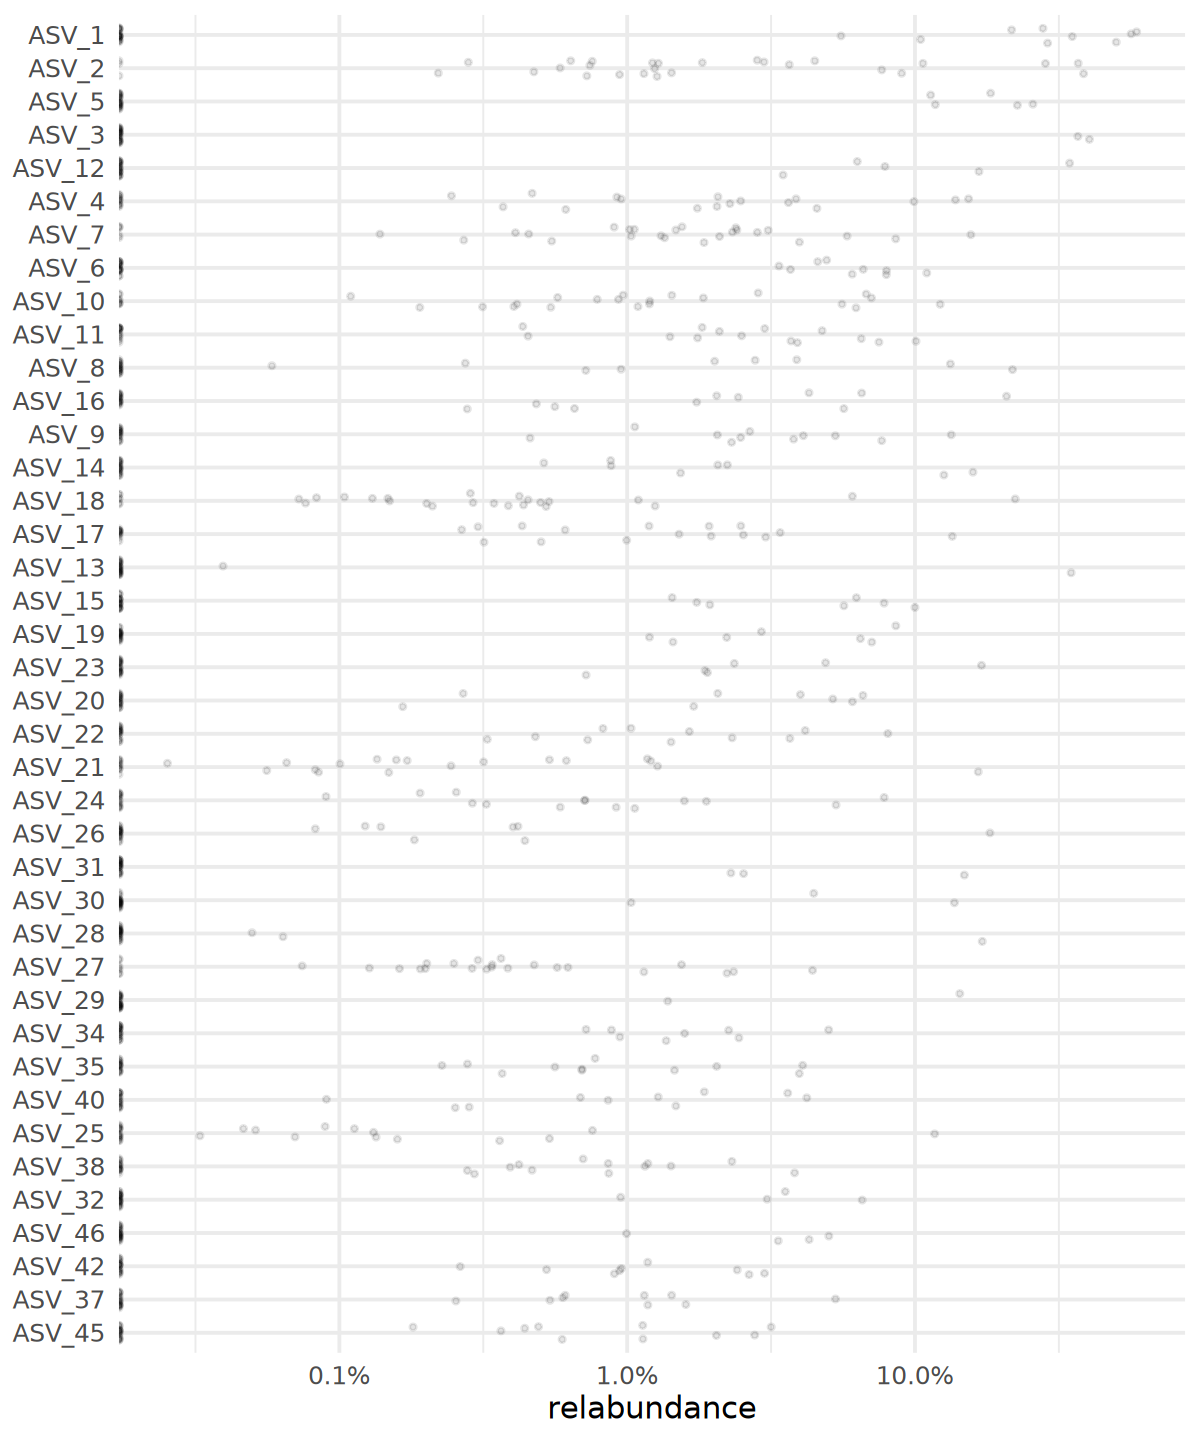

In [15]:
options(repr.plot.width = 10, repr.plot.height = 12)
tse <- transformAssay(tse, method = "relabundance")

plotAbundanceDensity(
    tse,
    layout = "jitter",
    assay.type = "relabundance",
    n = 40, point.size = 1, point.shape = 19,
    point.alpha = 0.1
) +
    scale_x_log10(label = scales::percent) +
        theme_minimal(base_size = 18) 


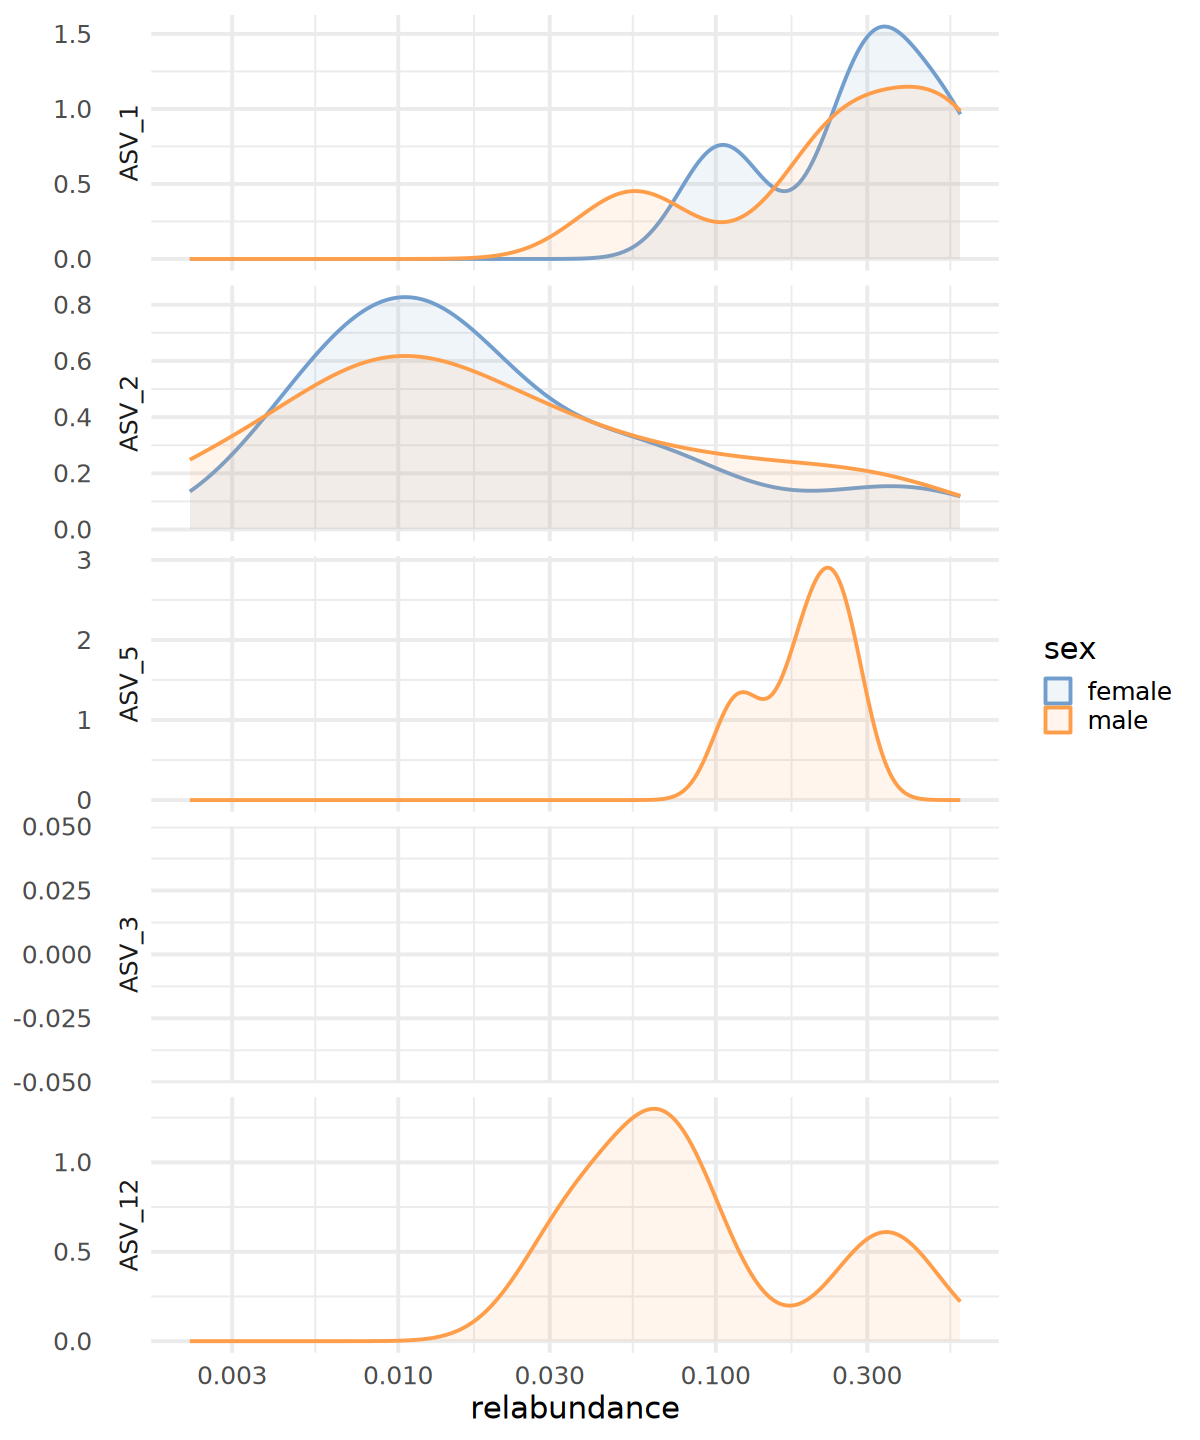

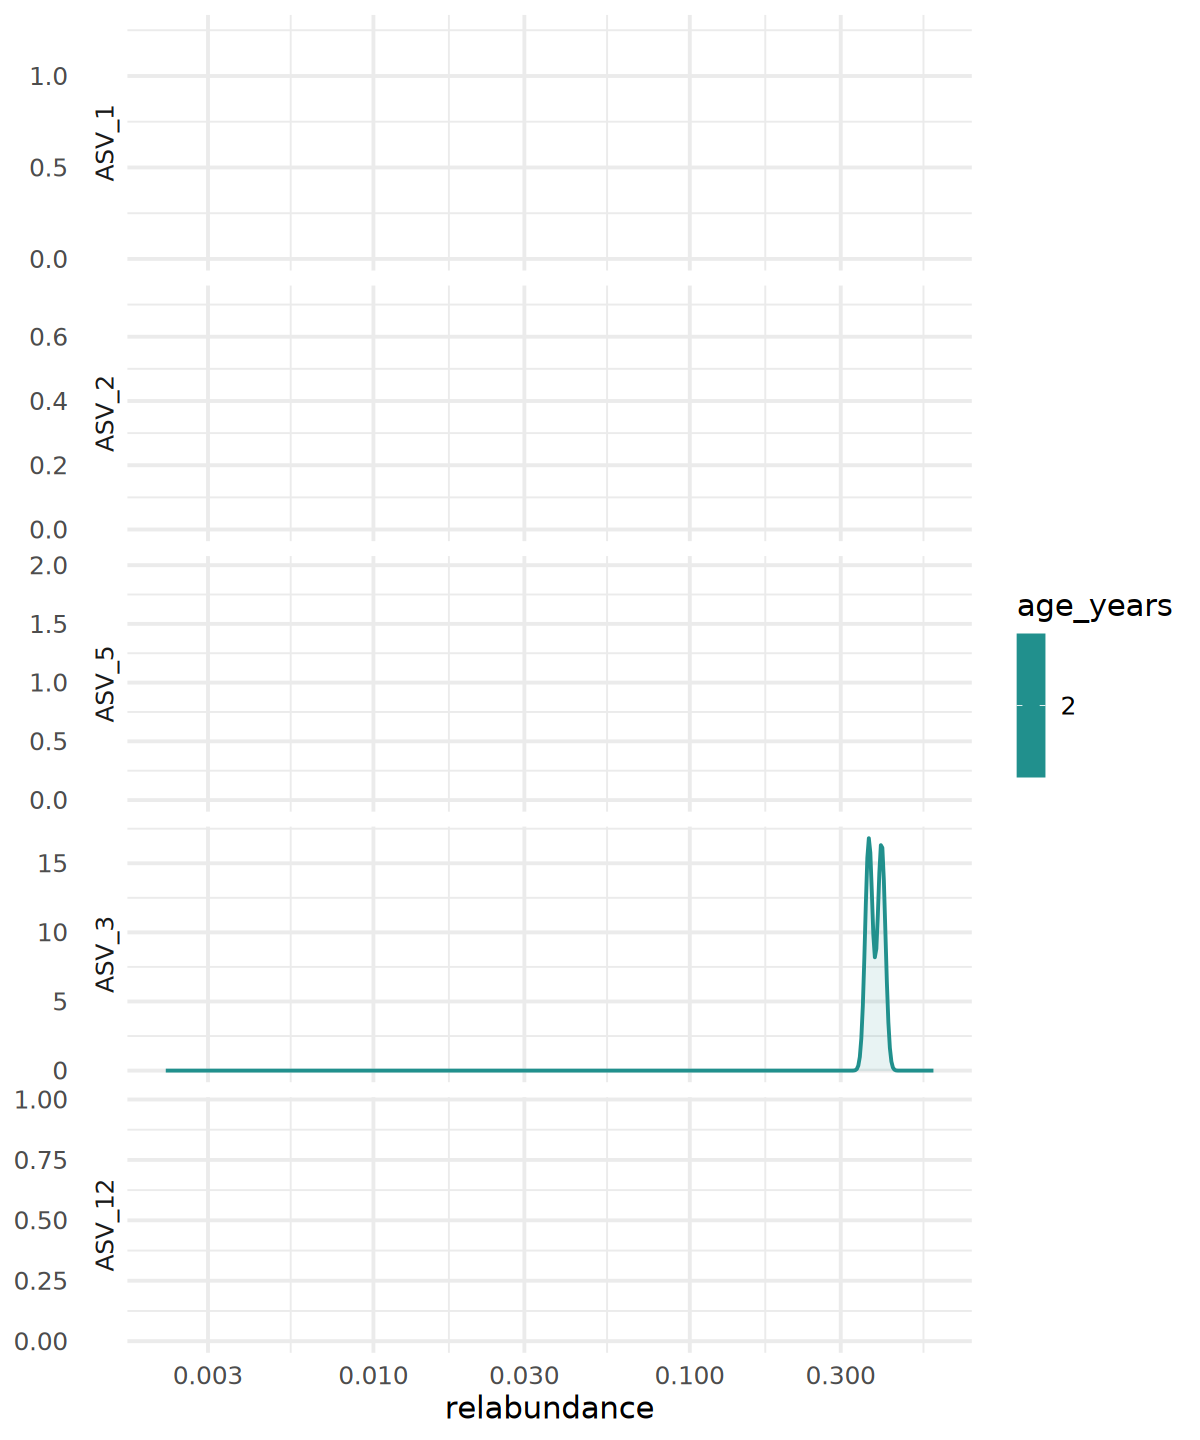

In [16]:
plotAbundanceDensity(
    tse,
    layout = "density",
    assay.type = "relabundance",
    n = 5, colour.by = "sex",
    point.alpha = 0.1
) +
    scale_x_log10() +
        theme_minimal(base_size = 18) 


plotAbundanceDensity(
    tse,
    layout = "density",
    assay.type = "relabundance",
    n = 5, colour.by = "age_years",
    point.alpha = 0.1
) +
    scale_x_log10() +
        theme_minimal(base_size = 18) 

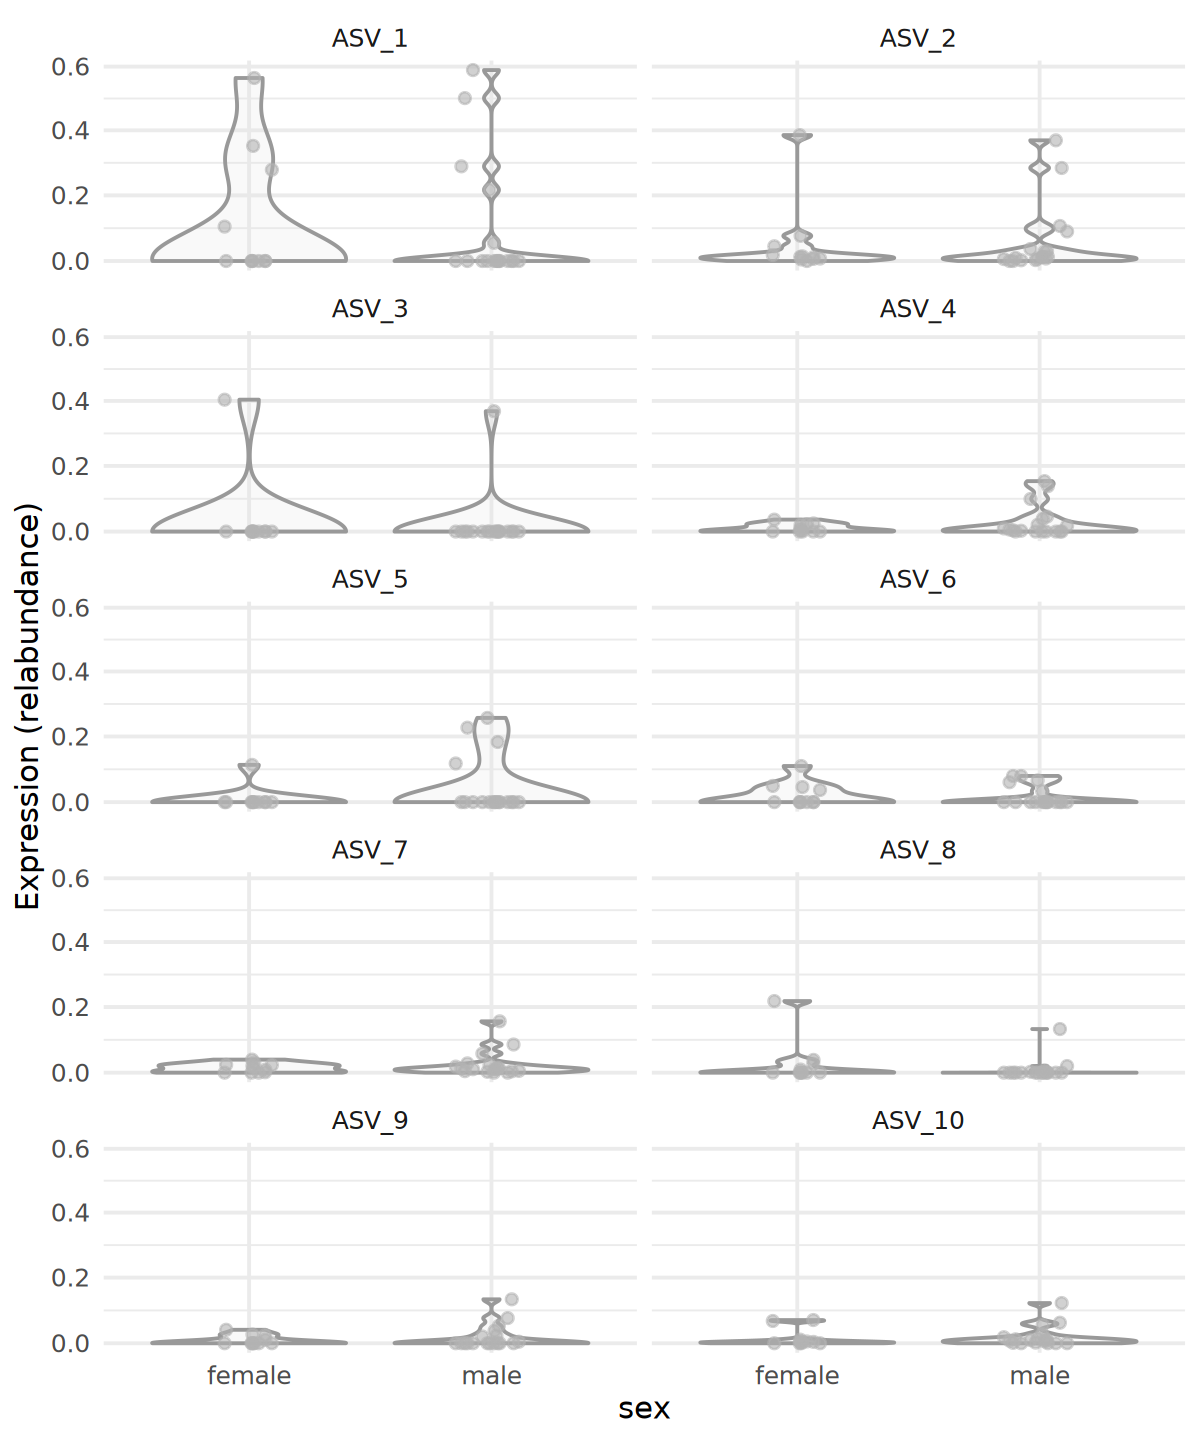

In [17]:
# the native plotExpression()  function from scater does a quasirandom thing to visually disperse the points, but this doesn't 
#    work when there's only one point for a ASV x sex combination
# replacing it with normal jitter

top <- getTop( tse, top = 10L, method = "mean")

p <- plotExpression(tse, features = top,
    x = "sex",
    assay.type = "relabundance",
    point_alpha = 0.6
)

# 
quasirandom_layers <- which(
    sapply(
        p$layers,
        function(x) inherits(x$position, "PositionQuasirandom")
    )
)

for (i in quasirandom_layers) {
    p$layers[[i]]$position <- position_jitter(        width = 0.15,
        height = 0
    )
}

p + scale_y_continuous(trans = scales::pseudo_log_trans(base = 10)) +
        theme_minimal(base_size = 18) 

### Add & Plot Prevalence

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


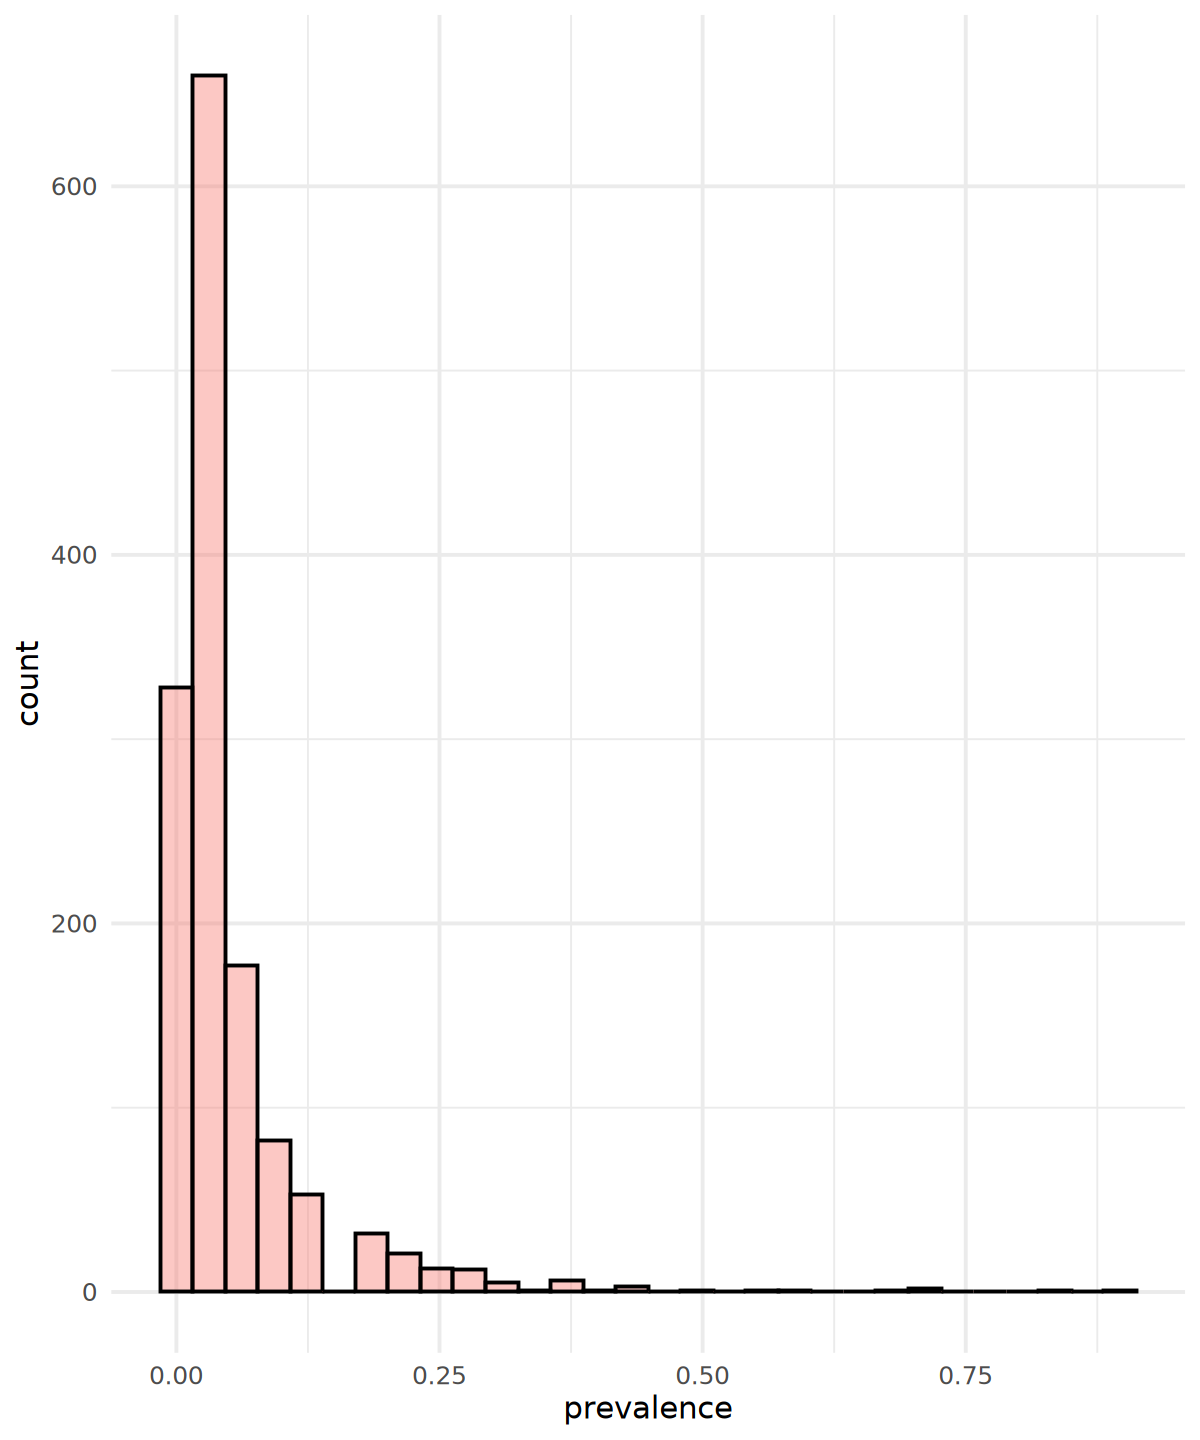

In [18]:
# from tutorial: "Prevalence quantifies the frequency of samples
#    where certain microbes were detected (above a given detection threshold). 
#    Prevalence can be given as sample size (N) or percentage (unit interval). " 



tse <- addPrevalence(tse, detection = 0.1 / 100, as.relative = TRUE)  # 0.01% relative abundance threshold
plotHistogram(tse, row.var = "prevalence") +
        theme_minimal(base_size = 18) 


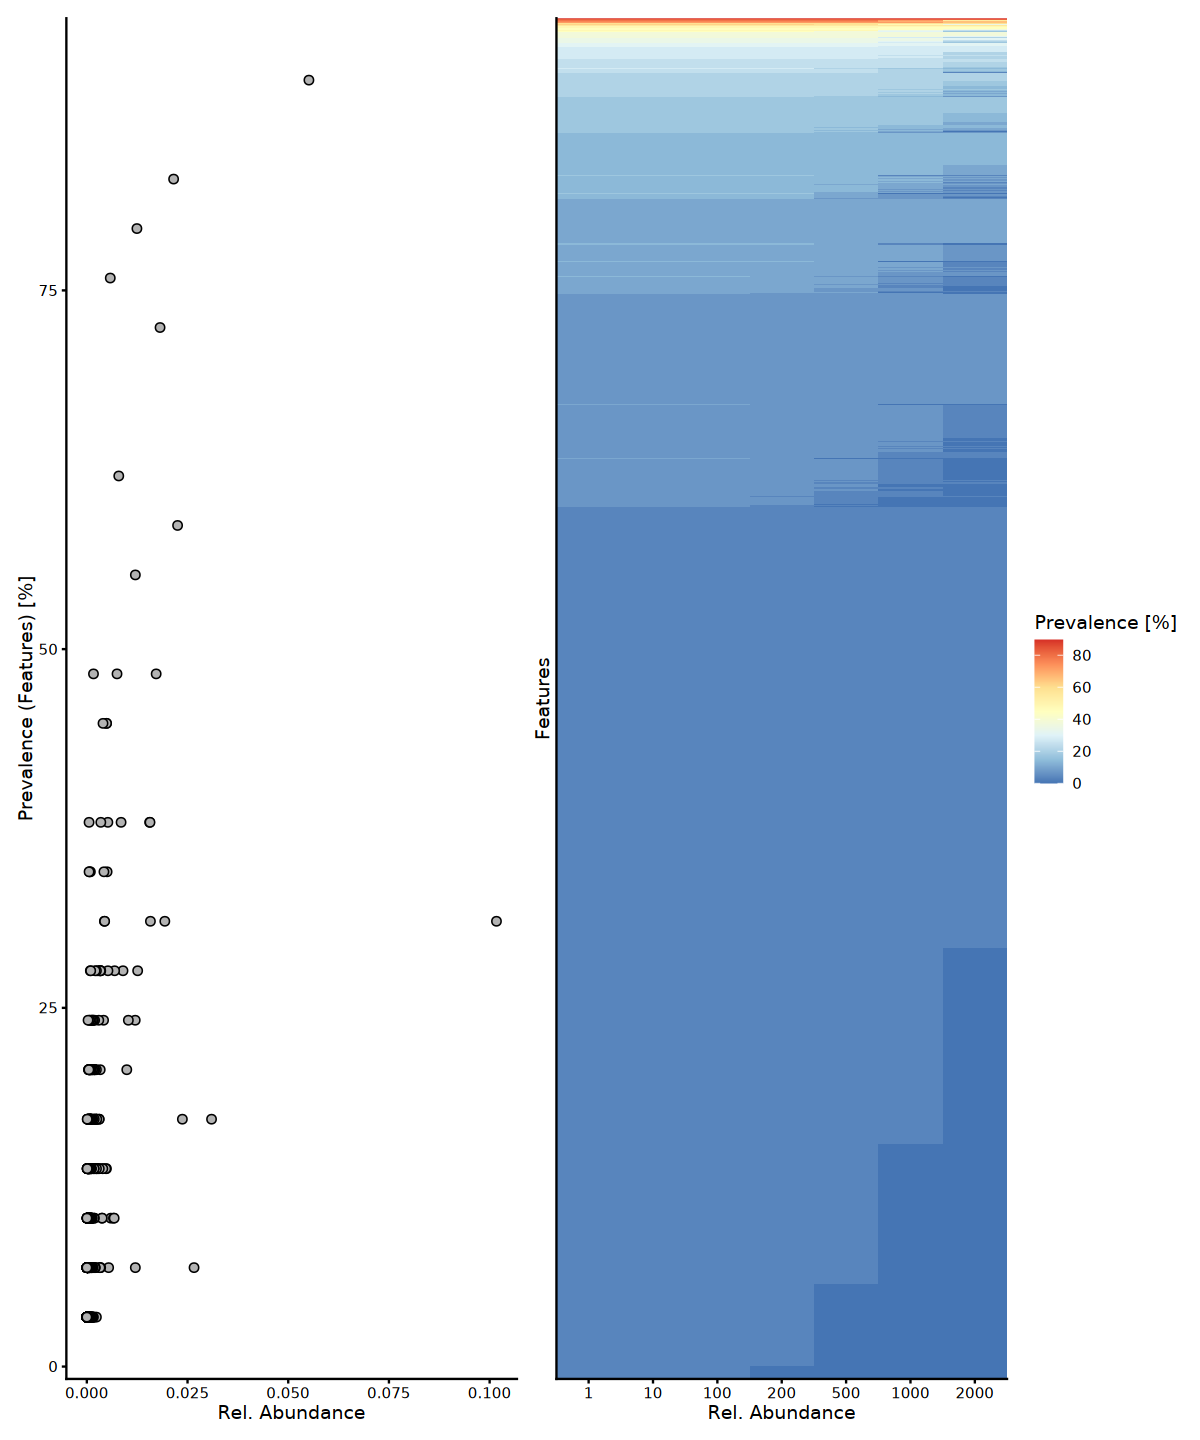

In [19]:
# "Most of the features are present only in a minority of the samples 
# with a specified abundance threshold. Similar conclusion can 
# be made with visualizations generated with the 
# plotPrevalentAbundance() or plotRowPrevalence() functions.



p1 <- plotPrevalentAbundance(tse, as.relative = TRUE)

# Remove y axis text as there are so many features that one cannot read them
p2 <- plotRowPrevalence(tse, as.relative = TRUE) +
    theme(
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank()
    )

p1 + p2

In [20]:
# plotPrevalence(tse, as.relative = TRUE)

# # "The plot shows the relationship between microbial relative abundance and 
# # prevalence across samples. Features with higher prevalence (yellow) 
# # tend to have lower relative abundance, while less prevalent 
# # features (purple) can still reach higher abundances in some cases.



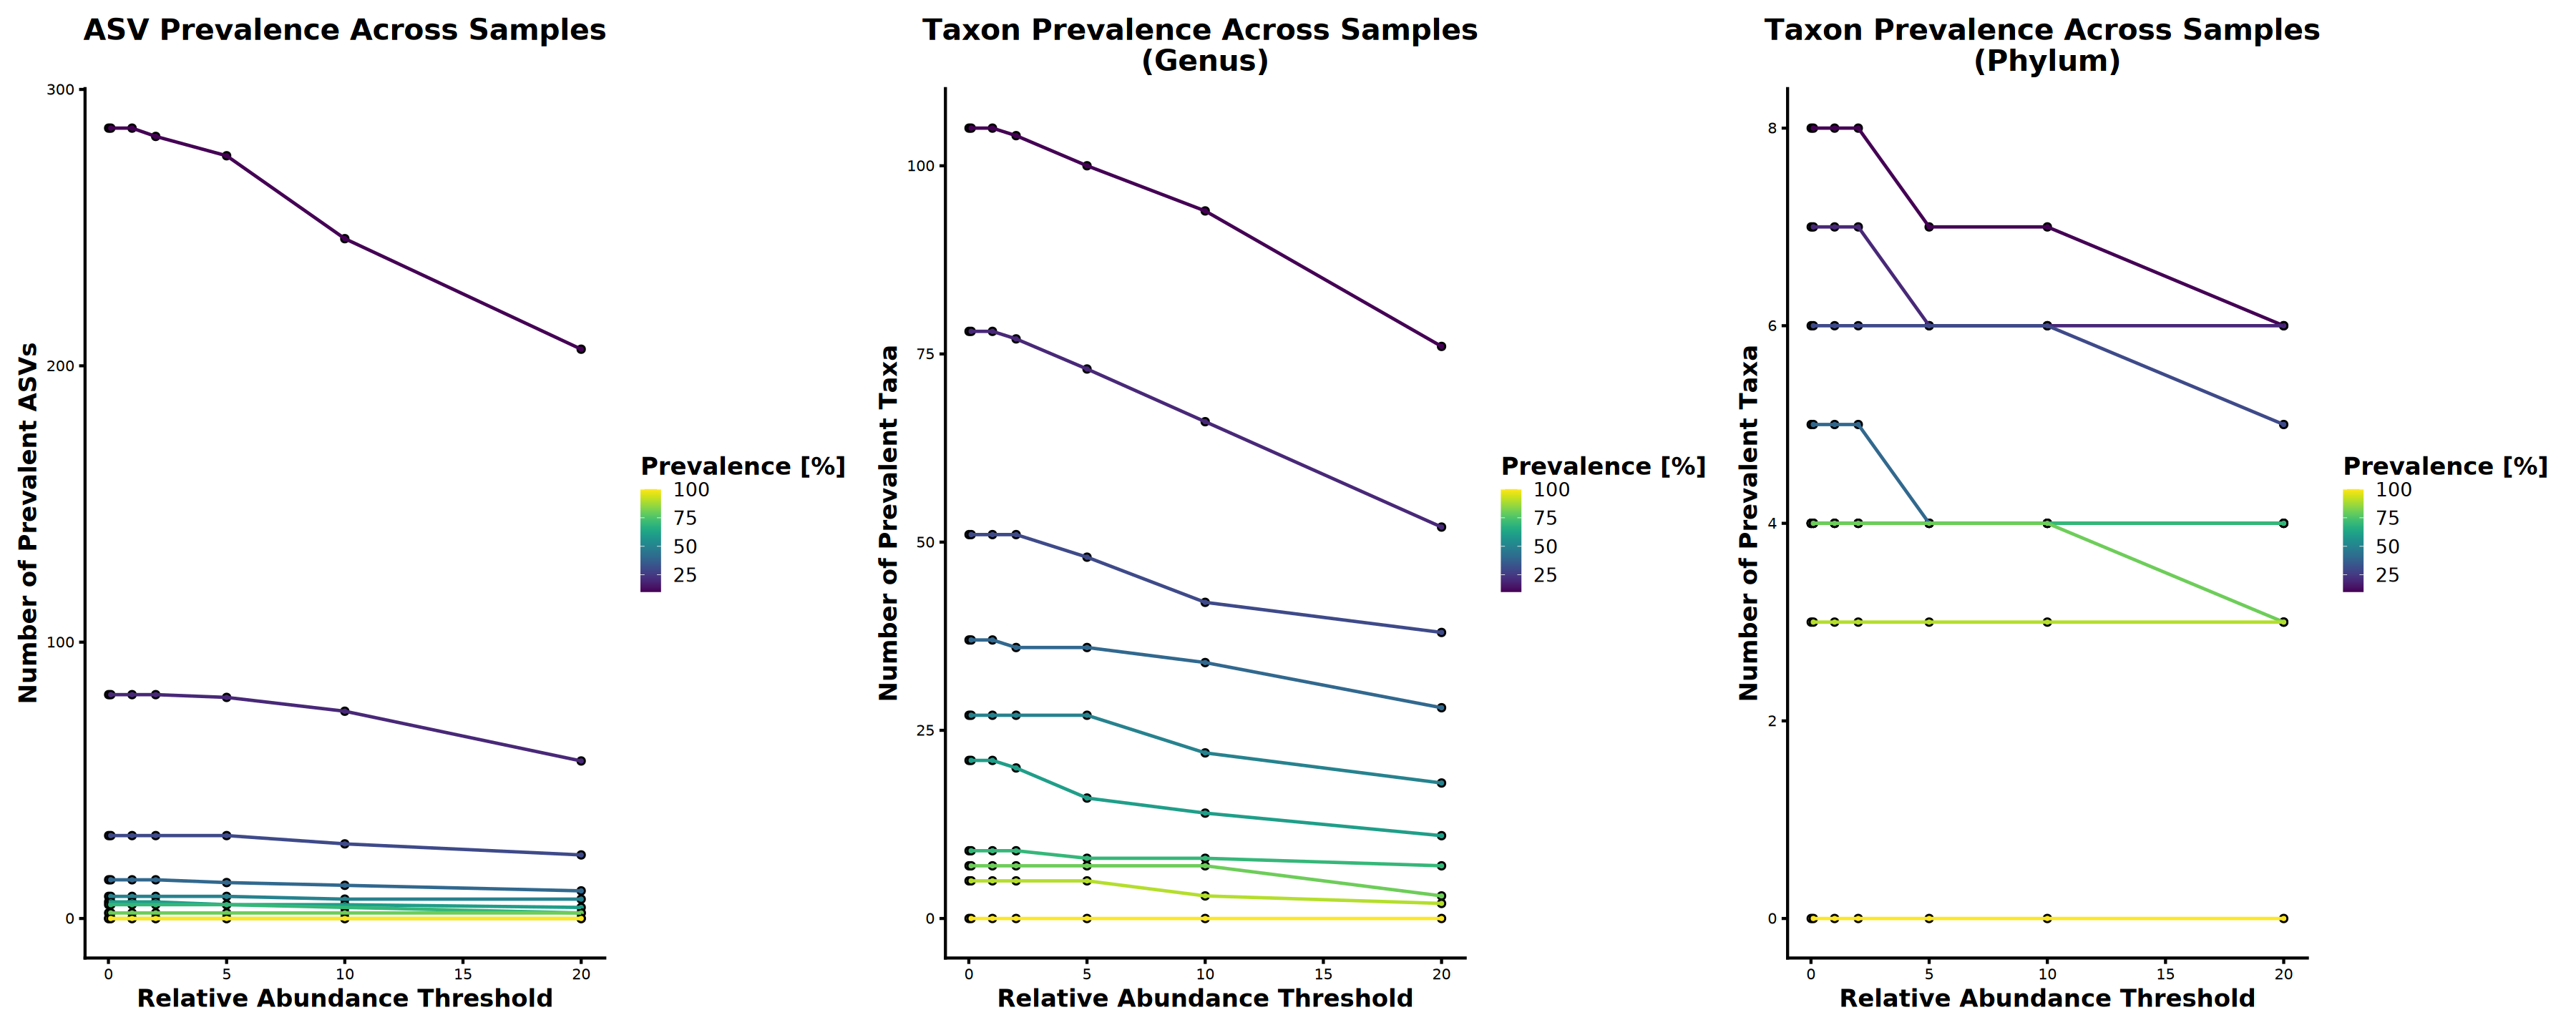

In [35]:
baseSize1 = 20


p_prev <- plotPrevalence(
    tse,
    as.relative = TRUE
) +
    labs(
        title = "ASV Prevalence Across Samples",
        x = "Relative Abundance Threshold",
        y = "Number of Prevalent ASVs"
    ) +
    theme_classic(base_size = baseSize1) +
    theme(
        plot.title = element_text(
            face = "bold",
            # size = 16,
            hjust = 0.5
        ),
        axis.title = element_text(
            face = "bold"
        ),
        axis.text = element_text(
            size = 12
        ),
        legend.title = element_text(
            face = "bold"
        )
    )



p_prev_genus <- plotPrevalence(
    tse_genus,
    as.relative = TRUE
) +
    labs(
        title = "Taxon Prevalence Across Samples \n(Genus)",
        x = "Relative Abundance Threshold",
        y = "Number of Prevalent Taxa"
    ) +
    theme_classic(base_size = baseSize1) +
    theme(
        plot.title = element_text(
            face = "bold",
            # size = 16,
            hjust = 0.5
        ),
        axis.title = element_text(
            face = "bold"
        ),
        axis.text = element_text(
            size = 12
        ),
        legend.title = element_text(
            face = "bold"
        )
    )




p_prev_phylum <- plotPrevalence(
    tse_phylum,
    as.relative = TRUE
) +
    labs(
        title = "Taxon Prevalence Across Samples \n(Phylum)",
        x = "Relative Abundance Threshold",
        y = "Number of Prevalent Taxa"
    ) +
    theme_classic(base_size = baseSize1) +
    theme(
        plot.title = element_text(
            face = "bold",
            # size = 16,
            hjust = 0.5
        ),
        axis.title = element_text(
            face = "bold"
        ),
        axis.text = element_text(
            size = 12
        ),
        legend.title = element_text(
            face = "bold"
        )
    )

options(repr.plot.width = 30, repr.plot.height = 12)


prev1 <- p_prev + p_prev_genus + p_prev_phylum
prev1

In [24]:
# save figure
ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.prevalence_v_abund_perSample.png'),
    plot = prev1,
    width = 30,
    height = 12,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.prevalence_v_abund_perSample.pdf'),
    plot = prev1,
    width = 30,
    height = 12,
    units = "in",
    bg = "white"
)
# save table for making figure in quarto report
saveRDS(tse, file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".tse_unfiltered_postTax.rds")))
# save table for making figure in quarto report
saveRDS(tse_genus, file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".tse_genus_unfiltered_postTax.rds")))
# save table for making figure in quarto report
saveRDS(tse_phylum, file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".tse_phylum_unfiltered_postTax.rds")))






In [45]:
# as.data.frame(rowData(tse))

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


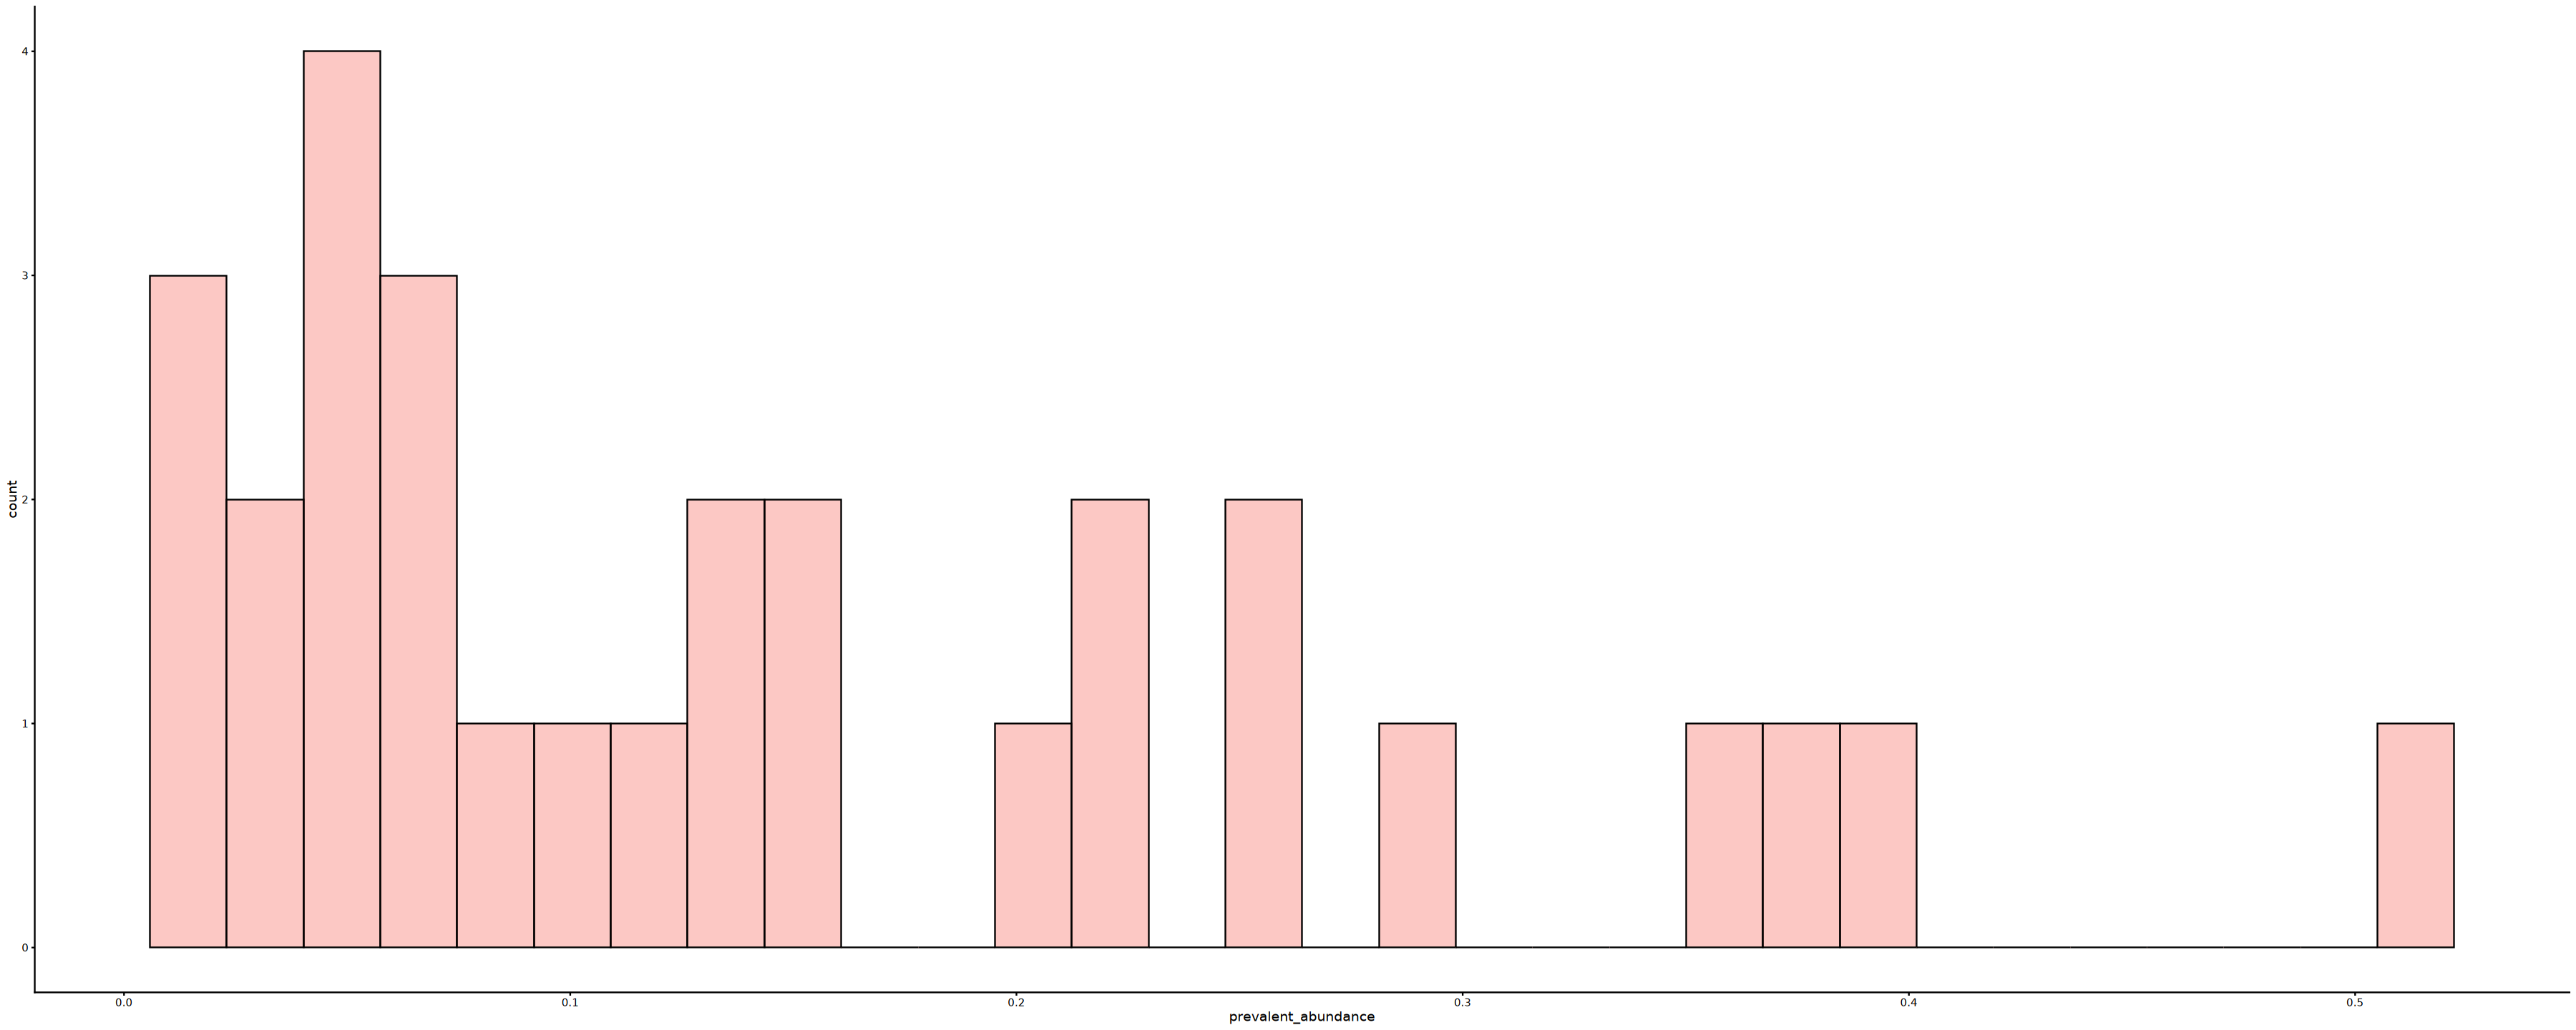

In [39]:
# Calculate the proportion of core taxa
tse <- addPrevalentAbundance(tse,
                             prevalence = 50 / 100, # minimum threshold
                             detection = 0.1 / 100) # minimum thresh. 

# Visualize
plotHistogram(tse, col.var = "prevalent_abundance")

In [28]:
# “What fraction of each sample's microbial community is made up of taxa 
#    that are common across the whole dataset?”


### Make Composition Plot

Don't filter TSE based on prevalence here. Just agglomerate rare taxa to 'Other' for visualization. Filter taxa based on prevalence for statistics.

In [29]:
# convert the abundance transformed data to a dataframe


groupLevels <- c("BF", "EU")



make_AbundPlot <- function(
    tse1,
    rank1,
    groupLevels1,
    group_col1,
    title1, 
    baseSizeA,
    other_prev_cutoff, 
    viridisOption1, 
    legendSize1,
    nRow_legend, 
    titleSiz1
) {

    # fix string type to get rid of NA
    rowData(tse1)[[rank1]] <- as.character(
        rowData(tse1)[[rank1]]
    )

    # replace former NA blank with unclassified
    rowData(tse1)[[rank1]][
        is.na(rowData(tse1)[[rank1]]) |
        rowData(tse1)[[rank1]] == ""
    ] <- "Unclassified"

    
    # Make relative-abundance assay version
    tse1_RA <- transformAssay(
        tse1,
        method = "relabundance"
    )


    # Agglomerate by prevalence cutoff
    tse1_RA_other <- agglomerateByPrevalence(
        tse1_RA,
        assay.type = "relabundance",
        prevalence = other_prev_cutoff,
        detection = 0.001
    )

    
    # Extract numeric portion of sample ID
    sample_number <- as.integer(
        str_extract(colnames(tse1_RA), "\\d+")
    )

    # Order samples first by group, then numerically within group
    sample_order <- colnames(tse1_RA)[
        order(
            factor(
                colData(tse1_RA)[[group_col1]],
                levels = groupLevels1
            ),
            sample_number
        )
    ]

    # Reorder samples
    tse_plot <- tse1_RA_other[, sample_order]

    # Plot
    figA <- plotAbundance(
        tse_plot,
        rank = rank1,
        assay.type = "relabundance"
    ) +
        scale_y_continuous(
            labels = label_percent(accuracy = 1),
            expand = expansion(mult = c(0, 0))
        ) +
        labs(
            title = title1,
            x = NULL,
            y = "Relative abundance",
            fill = rank1
        ) +
        theme_classic(base_size = baseSizeA) +
        theme(
              plot.title = element_text(
                    face = "bold",
                    size = titleSiz1,
                    hjust = 0.5
                ),
            axis.text.x = element_text(
                angle = 90,
                hjust = 1,
                vjust = 0.5
            ),
            axis.title.y = element_text(face = "bold"),
            legend.title = element_text(face = "bold")
        ) +
        scale_fill_viridis_d(option = viridisOption1) 


    # genus has too many elements, so put legend on the bottom and 
    # wrap the rows of names 
    if (rank1 == "Genus") {
        figA <- figA +
            theme(
                legend.position = "bottom",
                # shrink legend so hopefully more things fit
                legend.text = element_text(size = legendSize1)
                )   +
            guides(                   
                fill = guide_legend(
                    nrow = nRow_legend,
                    byrow = TRUE
                )
            )
    } else {
        figA <- figA +
         theme(legend.text = element_text(size = legendSize1))

    }

    return(figA)
}


# Phylum




Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


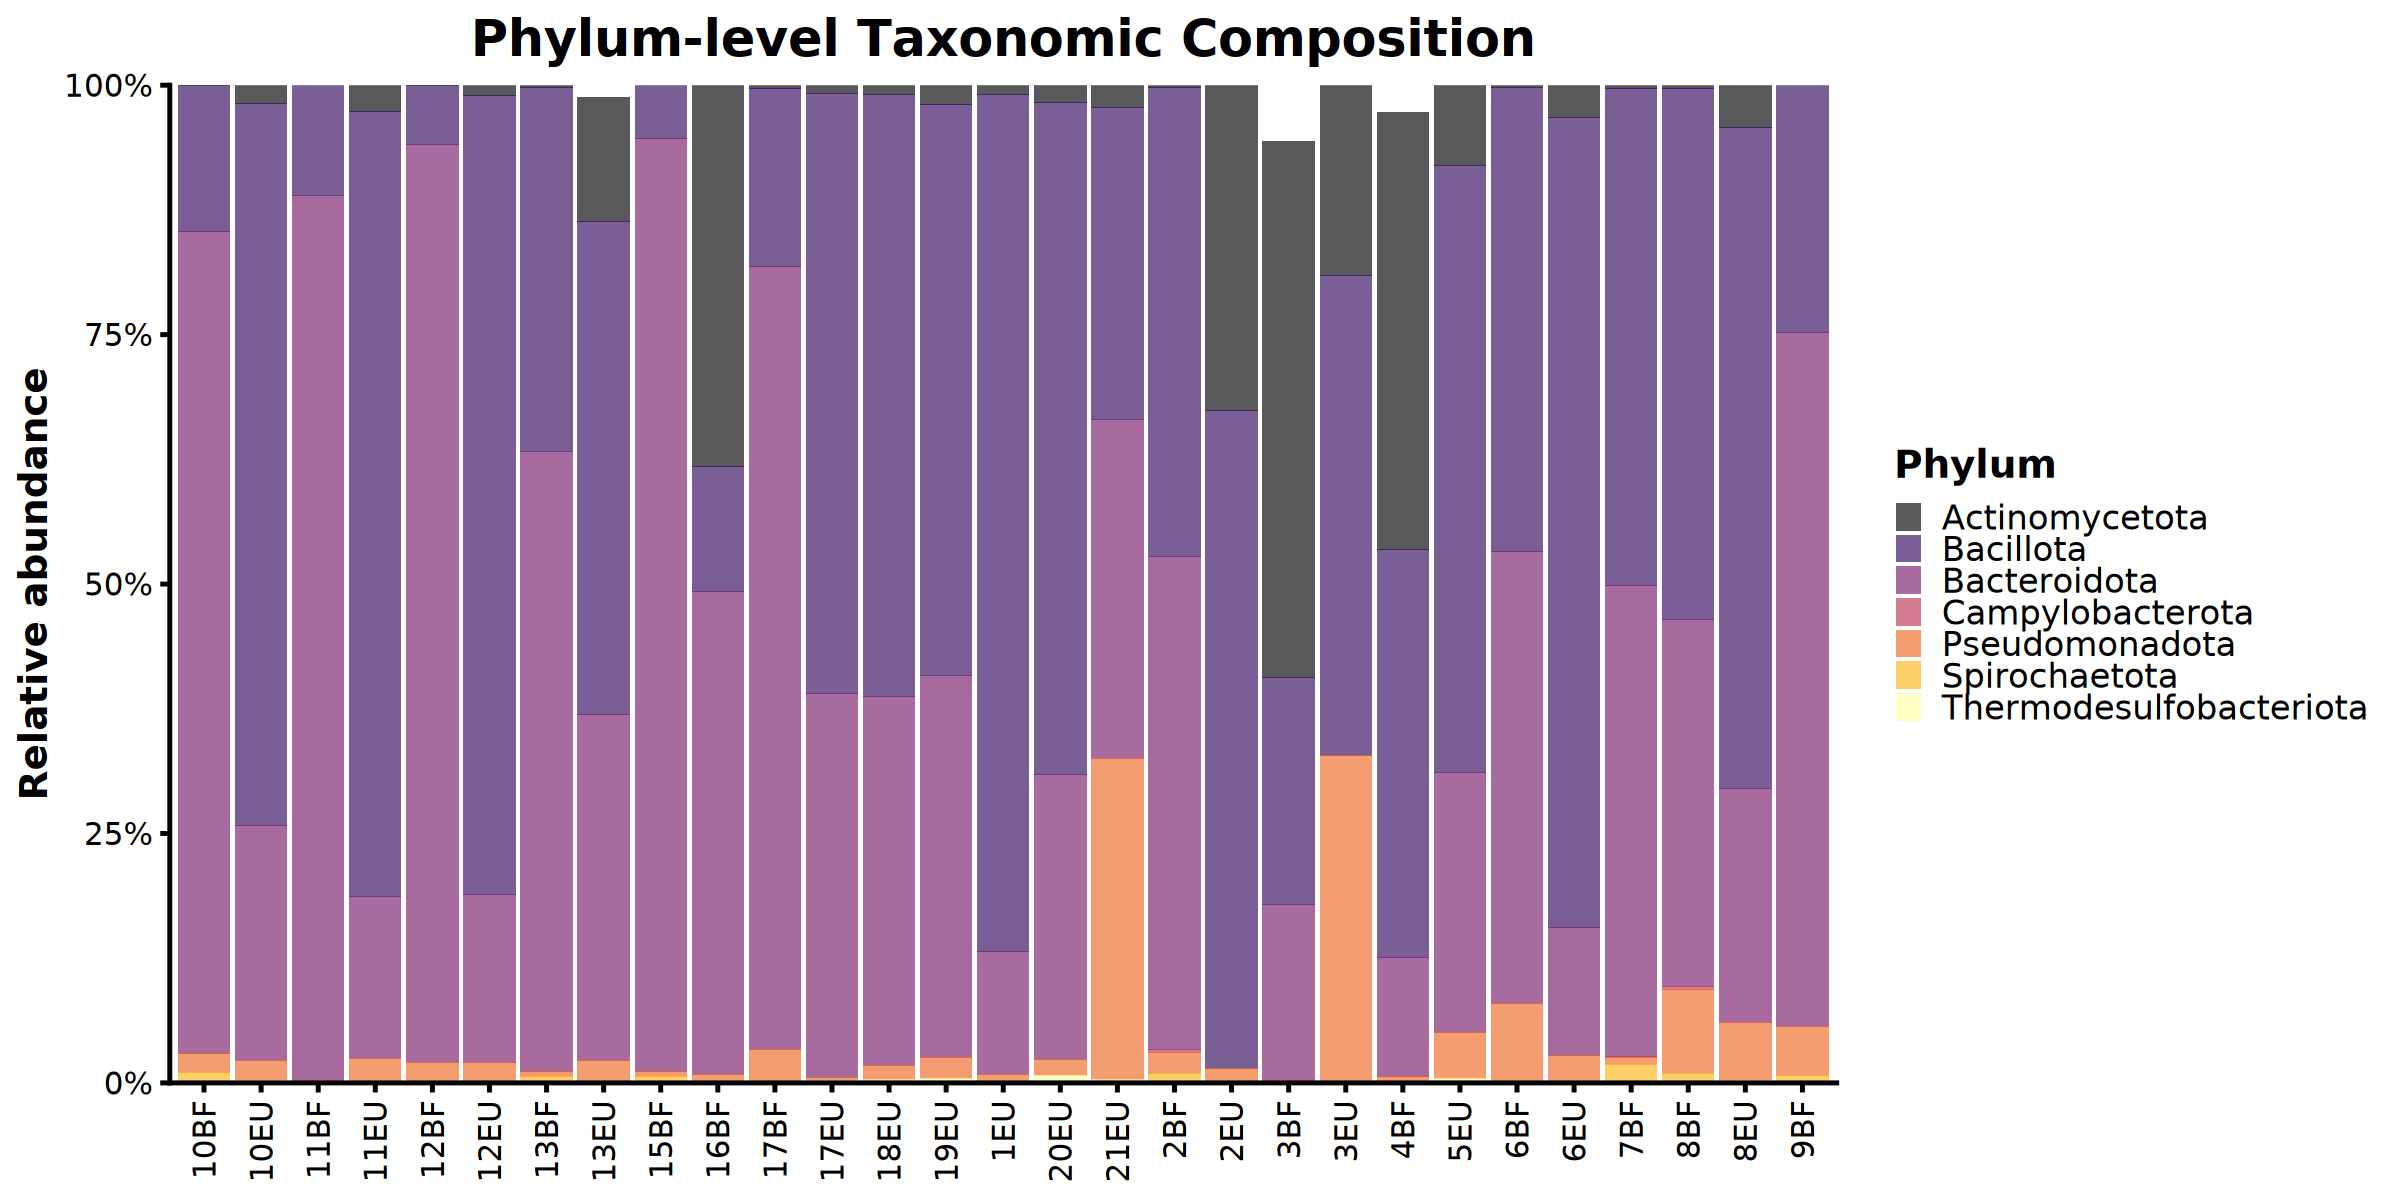

In [30]:
options(repr.plot.width = 20, repr.plot.height = 10)


pP <- make_AbundPlot(tse1 = tse_phylum, rank1 = "Phylum", 
                     groupLevels1  = groupLevels , 'population_group', 
                          title1 = "Phylum-level Taxonomic Composition", baseSizeA = 23, other_prev_cutoff = 0.1, 
                    viridisOption1 = "B", legendSize1 = 20, titleSiz1 = 30)
pP




In [46]:
# as.data.frame(rowData(tse_genus))

tse_phylum_RA <- transformAssay(
        tse_phylum,
        method = "relabundance"
    )

In [47]:
# as.data.frame(rowData(tse_genus))

tse_genus_RA <- transformAssay(
        tse_genus,
        method = "relabundance"
    )

In [49]:
# tse_genus_RA
tse_phylum_RArel_abund <- assay(tse_phylum_RA, "relabundance")
tse_phylum_RArel_abund

,10BF,10EU,11BF,11EU,12BF,12EU,13BF,13EU,15BF,16BF,⋯,3BF,3EU,4BF,5EU,6BF,6EU,7BF,8BF,8EU,9BF
Actinomycetota,0.0001947546,0.017877289,0.0000000000,0.02612100,0.0005894489,0.01066782,0.002622378,0.1250639241,0.000000000,0.381914580,⋯,0.537759913,0.1911870,0.4379304690,0.08080858,0.002010582,0.0321121376,0.003156917,0.003113501,0.042617409,0.000000000
Bacillota,0.1461308751,0.723856635,0.1100816980,0.78661922,0.0585519206,0.80060711,0.365020396,0.4939485198,0.053723564,0.125891016,⋯,0.227023267,0.4804822,0.4083306002,0.60835137,0.465714286,0.8119146225,0.498607242,0.532408718,0.662380780,0.247623574
Bacteroidota,0.8242015061,0.235962857,0.8878969090,0.16313167,0.9202279202,0.16825672,0.620629371,0.3467810671,0.935251077,0.483593520,⋯,0.176779779,0.0000000,0.1193834044,0.26052528,0.452698413,0.1285759796,0.471402043,0.368336636,0.234576844,0.696197719
Campylobacterota,0.0004544274,0.000000000,0.0000000000,0.00000000,0.0000000000,0.00000000,0.000000000,0.0000000000,0.000000000,0.000000000,⋯,0.000000000,0.0000000,0.0006559528,0.00000000,0.000000000,0.0002548582,0.001021356,0.002453062,0.000000000,0.000000000
Fusobacteriota,0.0000000000,0.000000000,0.0000000000,0.00000000,0.0000000000,0.00000000,0.000000000,0.0116483891,0.000000000,0.000000000,⋯,0.000000000,0.0000000,0.0000000000,0.00000000,0.000000000,0.0000000000,0.000000000,0.000000000,0.000000000,0.000000000
Patescibacteria,0.0000000000,0.000000000,0.0000000000,0.00000000,0.0000000000,0.00000000,0.000000000,0.0002272856,0.000000000,0.000000000,⋯,0.055963515,0.0000000,0.0277140046,0.00000000,0.000000000,0.0000000000,0.000000000,0.000000000,0.000000000,0.000000000
Pseudomonadota,0.0182420151,0.020133646,0.0013475954,0.02412811,0.0183220356,0.02046834,0.005026224,0.0223308143,0.004811065,0.008600884,⋯,0.002473526,0.3283308,0.0059855690,0.04574070,0.076825397,0.0260592545,0.007428041,0.083970186,0.057768924,0.049049430
Spirochaetota,0.0107764217,0.000000000,0.0006737977,0.00000000,0.0013753807,0.00000000,0.006701632,0.0000000000,0.006214293,0.000000000,⋯,0.000000000,0.0000000,0.0000000000,0.00000000,0.002751323,0.0000000000,0.018384401,0.009717898,0.000000000,0.007129278
Thermodesulfobacteriota,0.0000000000,0.002169574,0.0000000000,0.00000000,0.0009332940,0.00000000,0.000000000,0.0000000000,0.000000000,0.000000000,⋯,0.000000000,0.0000000,0.0000000000,0.00457407,0.000000000,0.0010831475,0.000000000,0.000000000,0.002656042,0.000000000
Verrucomicrobiota,0.0000000000,0.000000000,0.0000000000,0.00000000,0.0000000000,0.00000000,0.000000000,0.0000000000,0.000000000,0.000000000,⋯,0.000000000,0.0000000,0.0000000000,0.00000000,0.000000000,0.0000000000,0.000000000,0.000000000,0.000000000,0.000000000


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


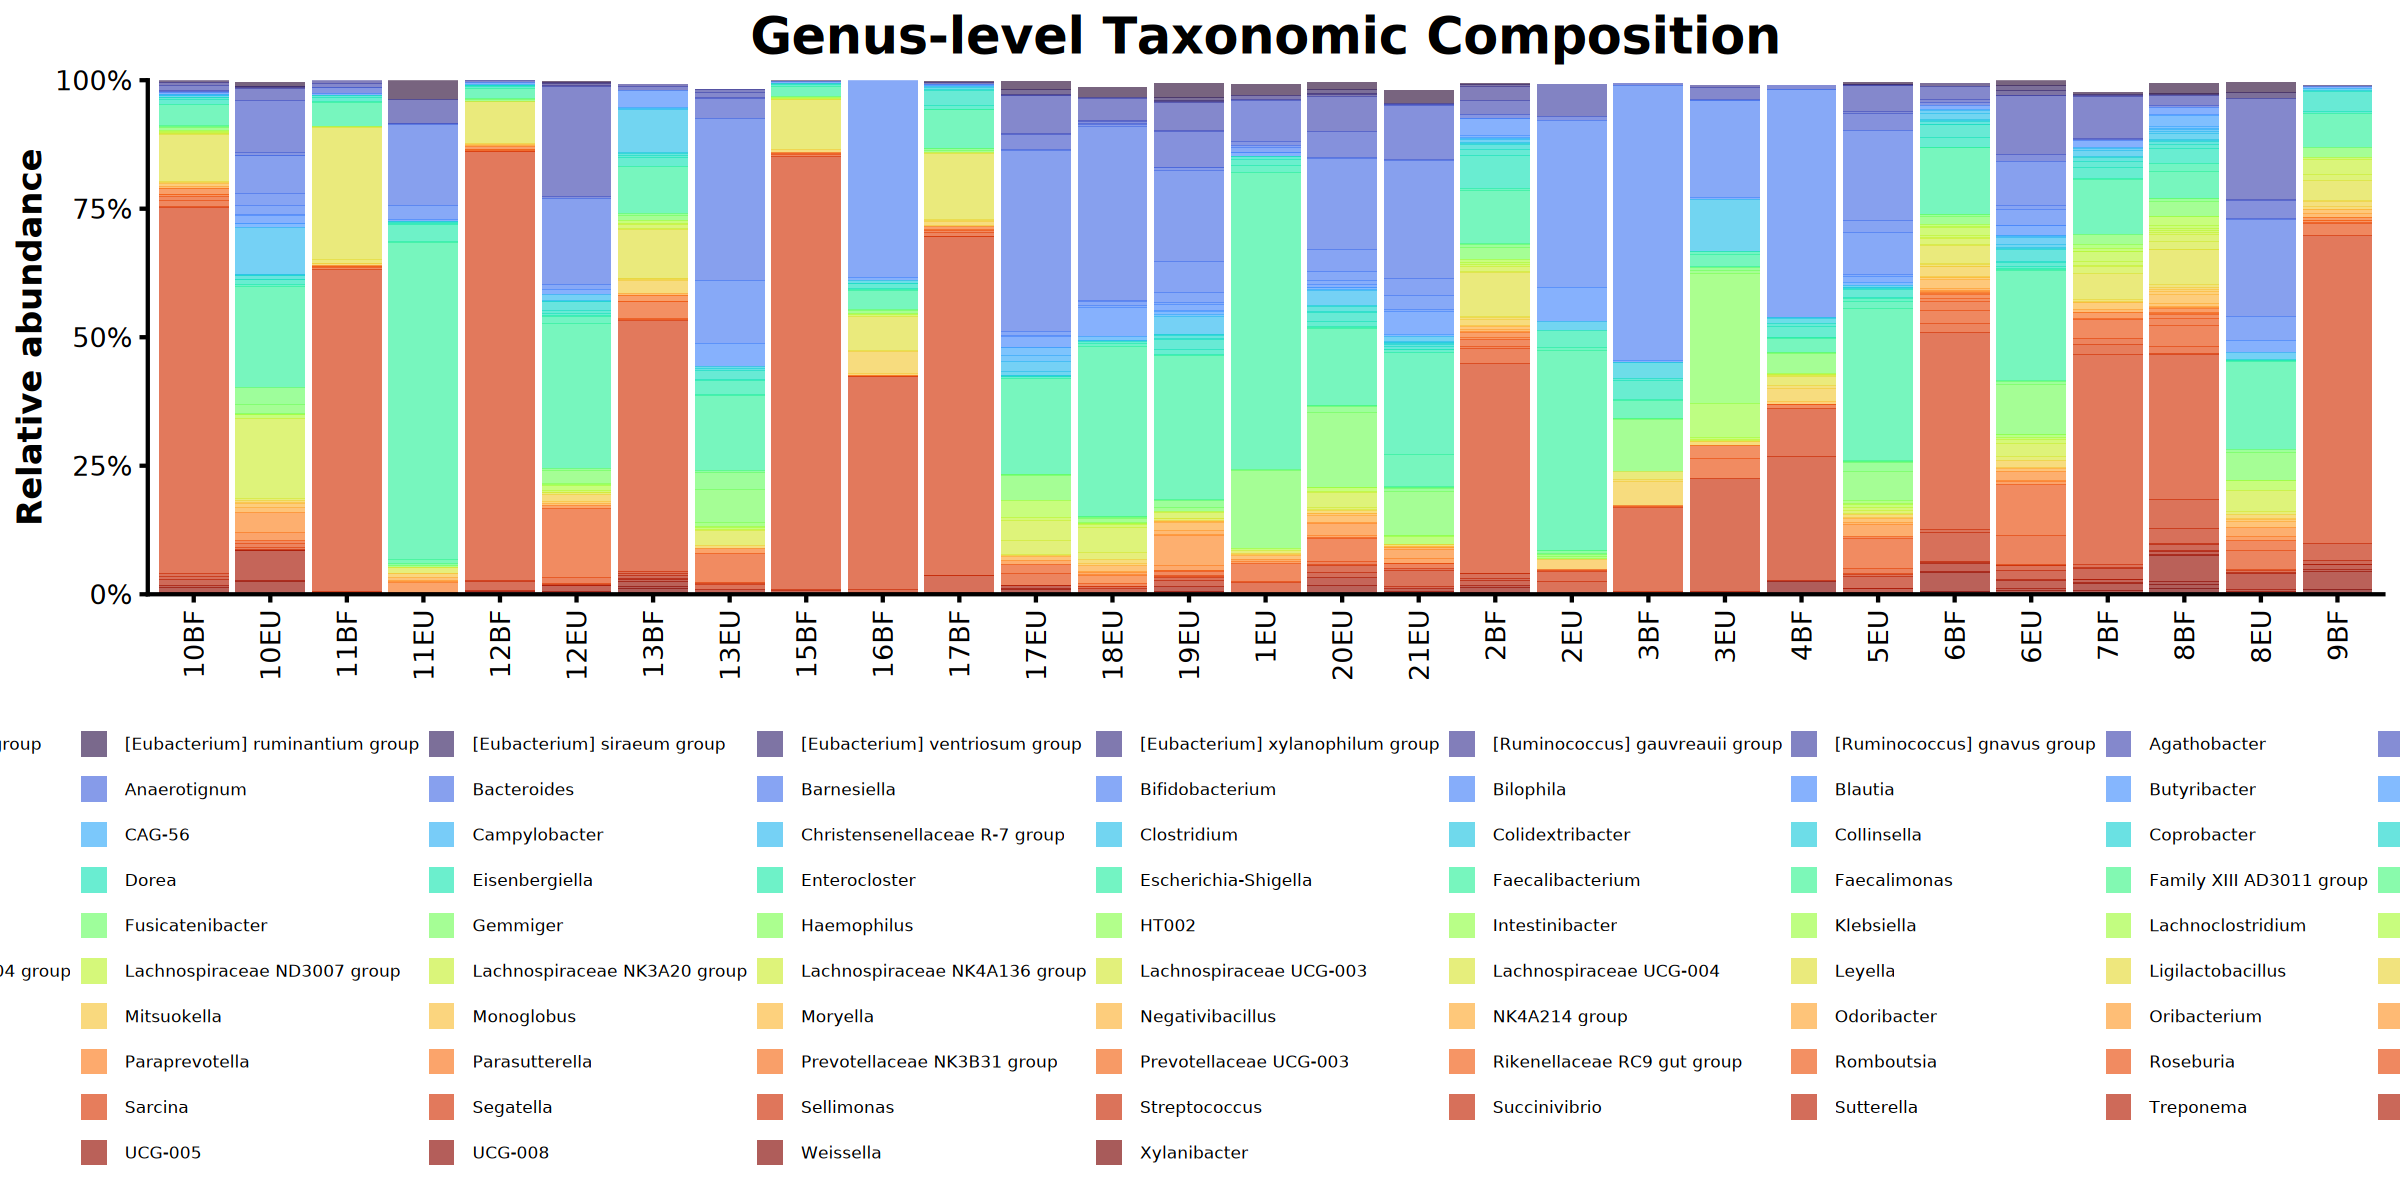

In [31]:
pG <- make_AbundPlot(tse1 = tse_genus, rank1 = "Genus", 
                     groupLevels1  = groupLevels , 'population_group', 
                          title1 = "Genus-level Taxonomic Composition", baseSizeA = 20, other_prev_cutoff = 0.1, 
                    viridisOption1 = "H", legendSize1 = 10, nRow_legend = 10, titleSiz1 = 30)
pG



In [183]:
# save figure phylum
ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.phylum.png'),
    plot = pP,
    width = 20,
    height = 10,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.phylum.pdf'),
    plot = pP,
    width = 20,
    height = 10,
    units = "in",
    bg = "white"
)



# save figure genus
ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.genus.png'),
    plot = pG,
    width = 30,
    height = 14,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.genus.pdf'),
    plot = pG,
    width = 30,
    height = 14,
    units = "in",
    bg = "white"
)





# Saved above, keeping this just in case
# # save table for making figure in quarto report
# saveRDS(tse, file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".tse_unfiltered_postTax.rds")))
# # save table for making figure in quarto report
# saveRDS(tse_genus, file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".tse_genus_unfiltered_postTax.rds")))
# # save table for making figure in quarto report
# saveRDS(tse_phylum, file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".tse_phylum_unfiltered_postTax.rds")))






### Make Plots for abundance distributions acrosss Top Phyla

In [39]:
# mean abundances per phylum (over samples)
tse_phylum_RA <- transformAssay(
    tse_phylum,
    method = "relabundance"
)

phylum_means <- rowMeans(
    assay(tse_phylum_RA, "relabundance")
)

# phyla with abundance >= 1%
major_phyla_minAbund <- rowData(tse_phylum_RA)$Phylum[
    phylum_means >= 0.01
]
major_phyla_minAbund


# top X phyla
major_phyla <- rowData(tse_phylum_RA)$Phylum[
    order(phylum_means, decreasing = TRUE)[1:6]
]

major_phyla

[1] "Actinomycetota" "Bacillota"      "Bacteroidota"   "Pseudomonadota"

[1] "Bacillota"       "Bacteroidota"    "Actinomycetota"  "Pseudomonadota" 
[5] "Patescibacteria" "Spirochaetota"

In [40]:
# extract phylum-level relative abundance
phylum_long <- as.data.frame(
    assay(tse_phylum_RA, "relabundance")
) |>
    mutate(
        Phylum = rowData(tse_phylum)$Phylum
    ) |>
    tidyr::pivot_longer(
        cols = -Phylum,
        names_to = "sample_id",
        values_to = "relative_abundance"
    )


sample_metadata <- as.data.frame(
    colData(tse_phylum)
) |>
    tibble::rownames_to_column(
        var = "sample_id"
    )

phylum_long <- phylum_long |>
    left_join(
        sample_metadata,
        by = "sample_id"
    )




phylum_long_onlyTopPhyla <- phylum_long |>
    dplyr::filter(Phylum %in% major_phyla_minAbund)



In [50]:
#### Wilcoxon test to see if the abundances are different
#    use rstatix
phylum_stats <- phylum_long_onlyTopPhyla |>
    group_by(Phylum) |>
    wilcox_test(
        relative_abundance ~ group,
        exact = FALSE
    ) |>
    adjust_pvalue(method = "BH") |>
    add_significance("p.adj")

phylum_stats



# add position info for plotting 
phylum_stats <- phylum_stats |>
    left_join(
        phylum_long_onlyTopPhyla |>
            group_by(Phylum) |>
            summarise(
                y.position = max(relative_abundance, na.rm = TRUE) * 1.15,
                .groups = "drop"
            ),
        by = "Phylum"
    )

# fix low bars 
phylum_stats <- phylum_stats |>
    mutate(
        y.position = case_when(
            Phylum == "Bacillota" ~ y.position * 1.3,
            Phylum == "Bacteroidota"   ~ y.position * 1.5,
            TRUE ~ y.position
        )
    )

Phylum,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
Actinomycetota,relative_abundance,BF,EU,14,15,45,9.374855e-03,0.0124998064,*
Bacillota,relative_abundance,BF,EU,14,15,10,3.718347e-05,0.0001487339,***
Bacteroidota,relative_abundance,BF,EU,14,15,185,5.202804e-04,0.0010405609,**
Pseudomonadota,relative_abundance,BF,EU,14,15,73,1.692019e-01,0.1692019217,ns


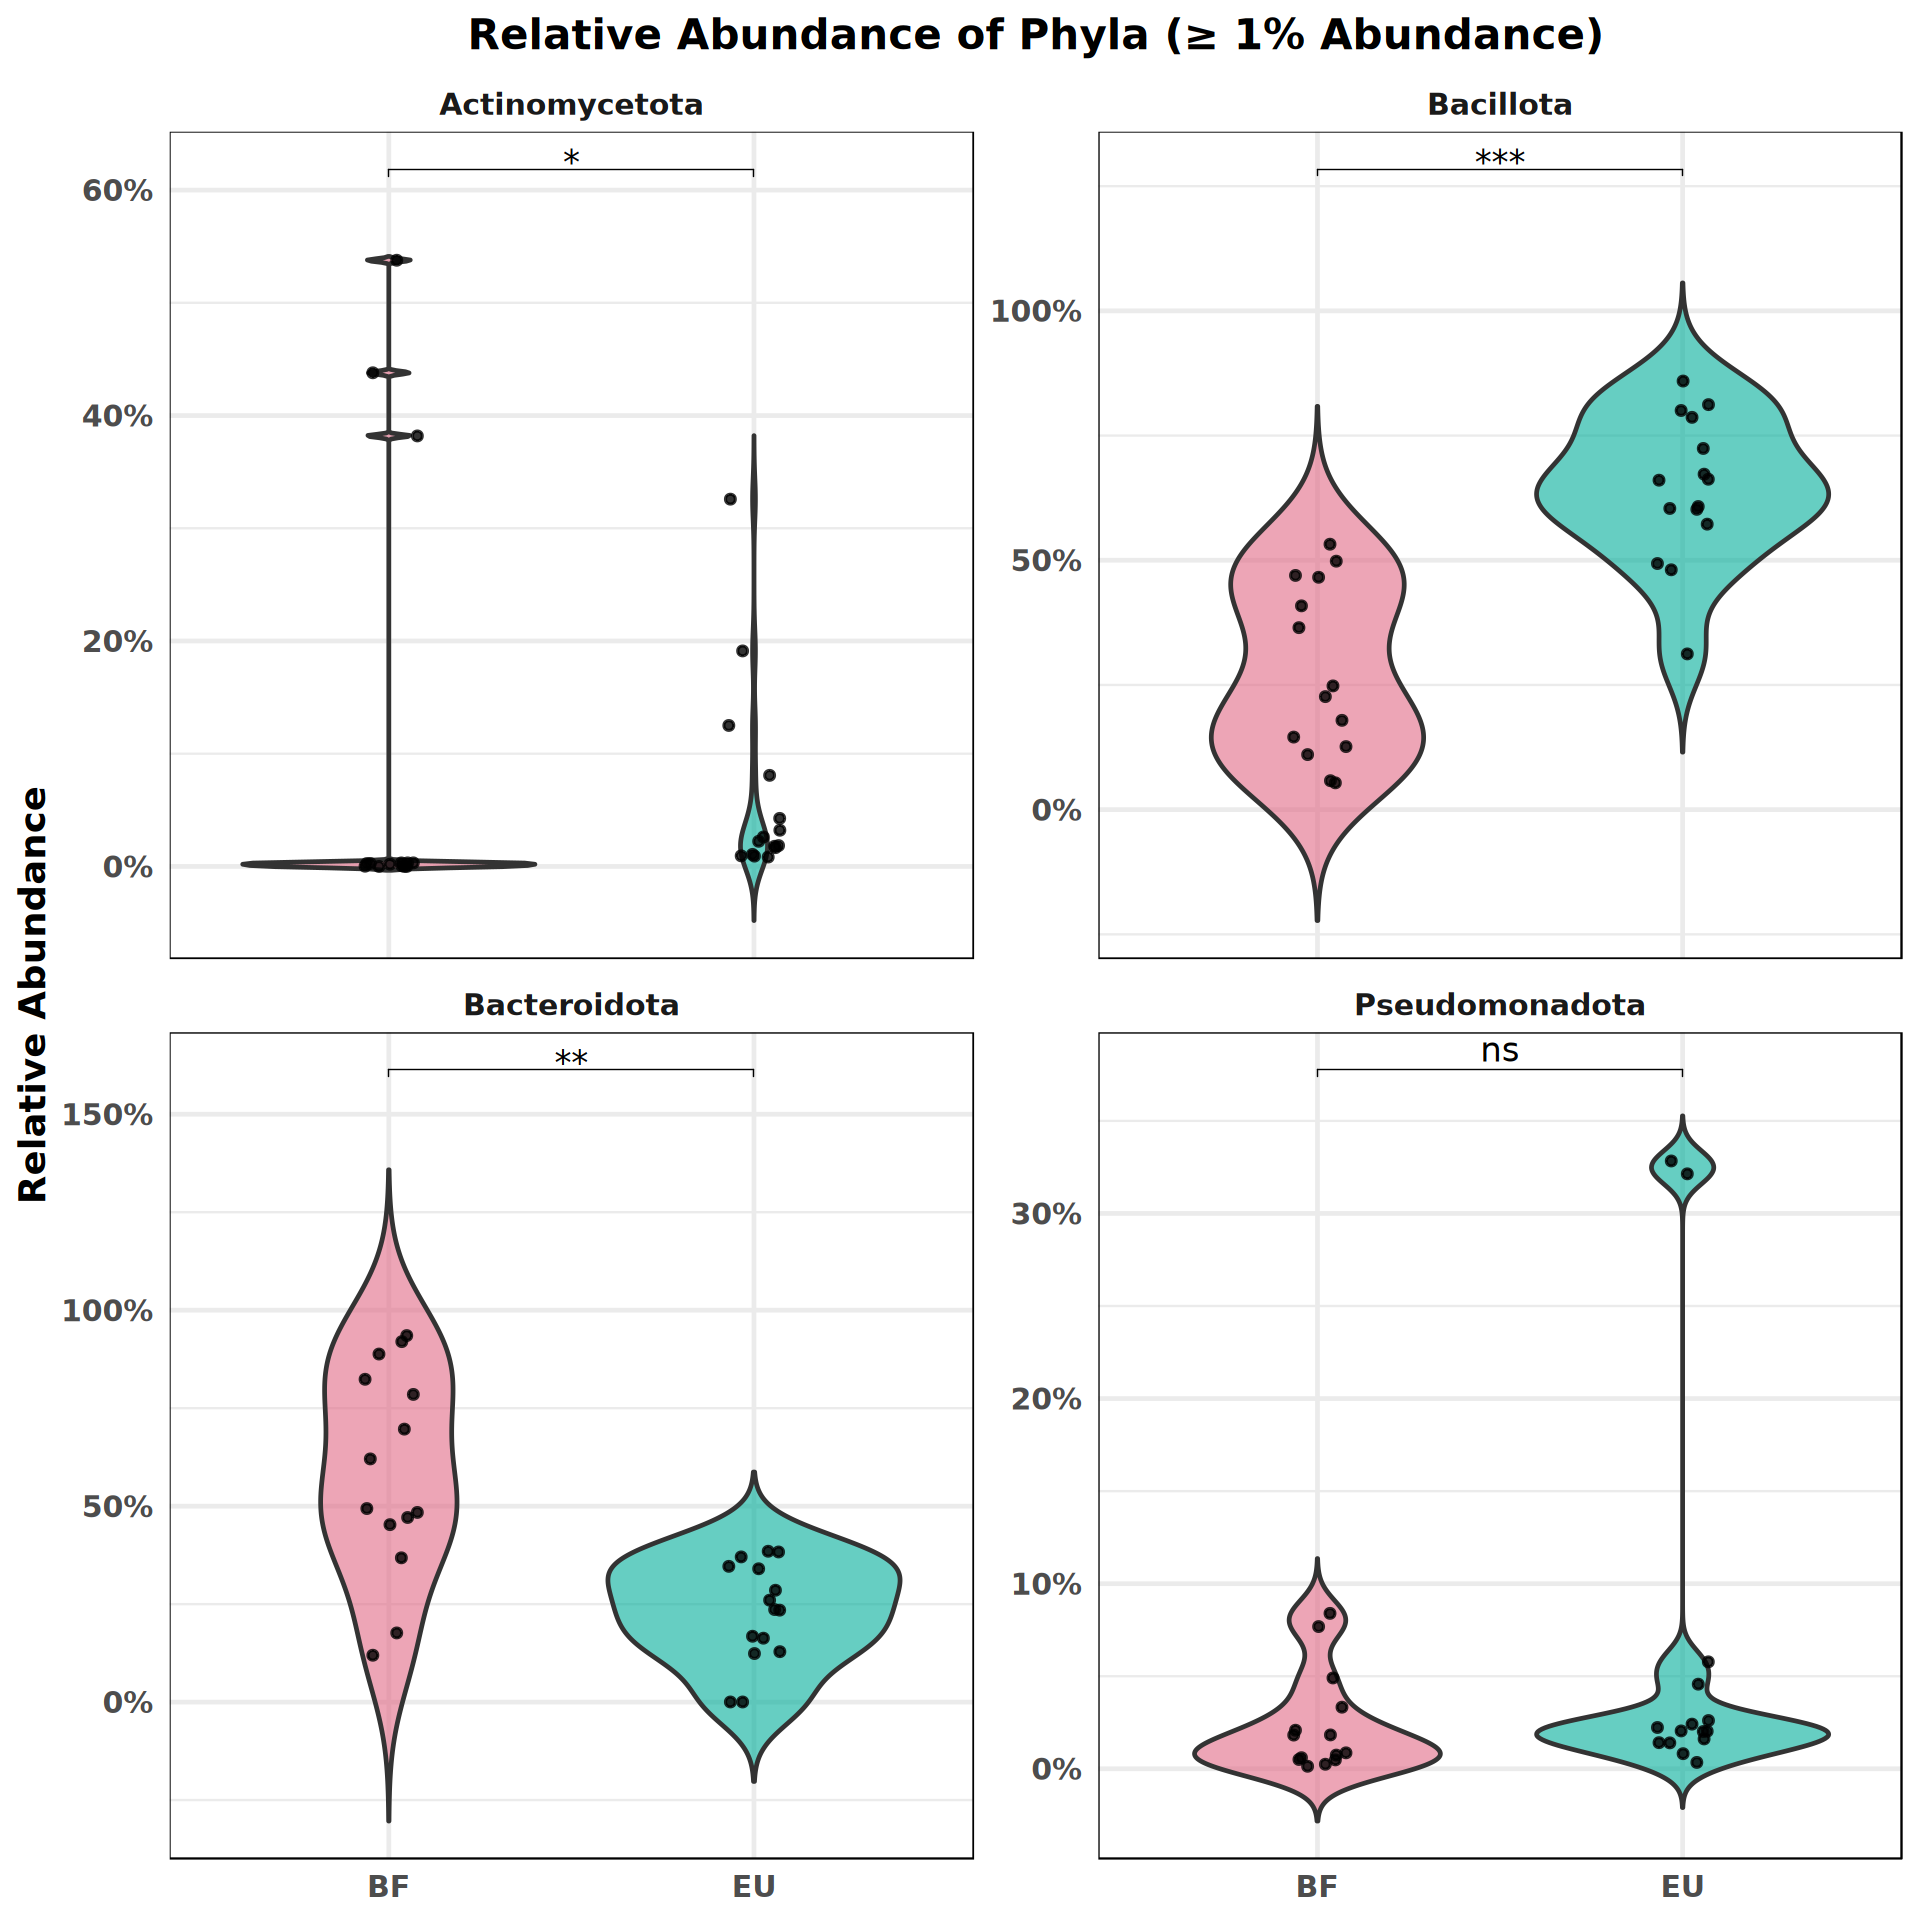

In [54]:
options(repr.plot.width = 16, repr.plot.height = 16)

indiv_phyla_abund <- phylum_long_onlyTopPhyla |>
    ggplot(
        aes(
            x = group,
            y = relative_abundance,
            fill = group
        )
    ) +
    geom_violin(
        trim = FALSE,
        alpha = 0.6,
        width = 0.8
    ) +
    geom_jitter(
        width = 0.08,
        size = 1.8,
        alpha = 0.8
    ) +

     # significance test within each facet   !!!!!!!!!!!!!!!
    stat_pvalue_manual(
        phylum_stats,
        label = "p.adj.signif",
        xmin = "group1",
        xmax = "group2",
        y.position = "y.position",
        tip.length = 0.01,
        size = 7
    ) +

    facet_wrap(
        ~ Phylum,
        scales = "free_y"
    ) +
    scale_y_continuous(
        labels = scales::label_percent(accuracy = 1)
    ) +
    labs(
        x = NULL,
        y = "Relative Abundance",
        title = "Relative Abundance of Phyla (≥ 1% Abundance)" 
    ) +
    theme_minimal(base_size = 22) +
    theme(
        legend.position = "none",
        strip.background = element_blank(),
        strip.text = element_text(face = "bold"),
        axis.title.y = element_text(face = "bold"),
        axis.text.y = element_text(face = "bold"),
        axis.text.x = element_text(face = "bold"),
        plot.title = element_text( face = "bold", size = 25, hjust = 0.5 ),
    
        # Lines around each subplot
        panel.border = element_rect(
            colour = "black",
            fill = NA,
            linewidth = 0.5
        )
    ) + scale_fill_manual(values = population_colors) 

indiv_phyla_abund

In [184]:
# save figure phylum
ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.TopPhyla.png'),
    plot = indiv_phyla_abund,
    width = 12,
    height = 12,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.TopPhyla.pdf'),
    plot = indiv_phyla_abund,
    width = 12,
    height = 12,
    units = "in",
    bg = "white"
)


# save table for quarto plot
write_tsv( 
    phylum_long_onlyTopPhyla,
    file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".taxaComposition.TopPhyla.tsv")),
    quote = "needed"
)


# save table for quarto plot
write_tsv( 
    phylum_stats,
    file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".taxaComposition.TopPhyla.stats.tsv")),
    quote = "needed"
)




### Run Principal Component Analysis on CLR transformed Read Counts

In [57]:
# First, CLR transform data

tse_clr_genus <- transformAssay(
    tse_genus ,
    assay.type = "counts",
    method = "clr",
    pseudocount = TRUE
)


tse_clr_phylum <- transformAssay(
    tse_phylum ,
    assay.type = "counts",
    method = "clr",
    pseudocount = TRUE
)







A pseudocount of 1 was applied.

A pseudocount of 1.5 was applied.



In [58]:
# PCA
tse_clr_genus <- runPCA(
    tse_clr_genus,
    assay.type = "clr",
     BSPARAM = BiocSingular::ExactParam())


tse_clr_phylum <- runPCA(
    tse_clr_phylum,
    assay.type = "clr",
    BSPARAM = BiocSingular::ExactParam())



In [59]:
tse_clr_genus

# A SingleCellExperiment-tibble abstraction: 29 × 32
# Features=163 | Cells=29 | Assays=counts, clr
   .cell group run_id    population_group age_years sex    reported_ethnicity
   <chr> <chr> <chr>     <chr>                <dbl> <chr>  <chr>             
 1 10BF  BF    ERR011058 BF                       6 female black african     
 2 10EU  EU    ERR011059 EU                       5 male   caucasian         
 3 11BF  BF    ERR011060 BF                       5 male   black african     
 4 11EU  EU    ERR011061 EU                       5 male   caucasian         
 5 12BF  BF    ERR011062 BF                       6 male   black african     
 6 12EU  EU    ERR011063 EU                       6 male   caucasian         
 7 13BF  BF    ERR011064 BF                       6 male   black african     
 8 13EU  EU    ERR011065 EU                       5 male   caucasian         
 9 15BF  BF    ERR011066 BF                       6 male   black african     
10 16BF  BF    ERR011067 BF               

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


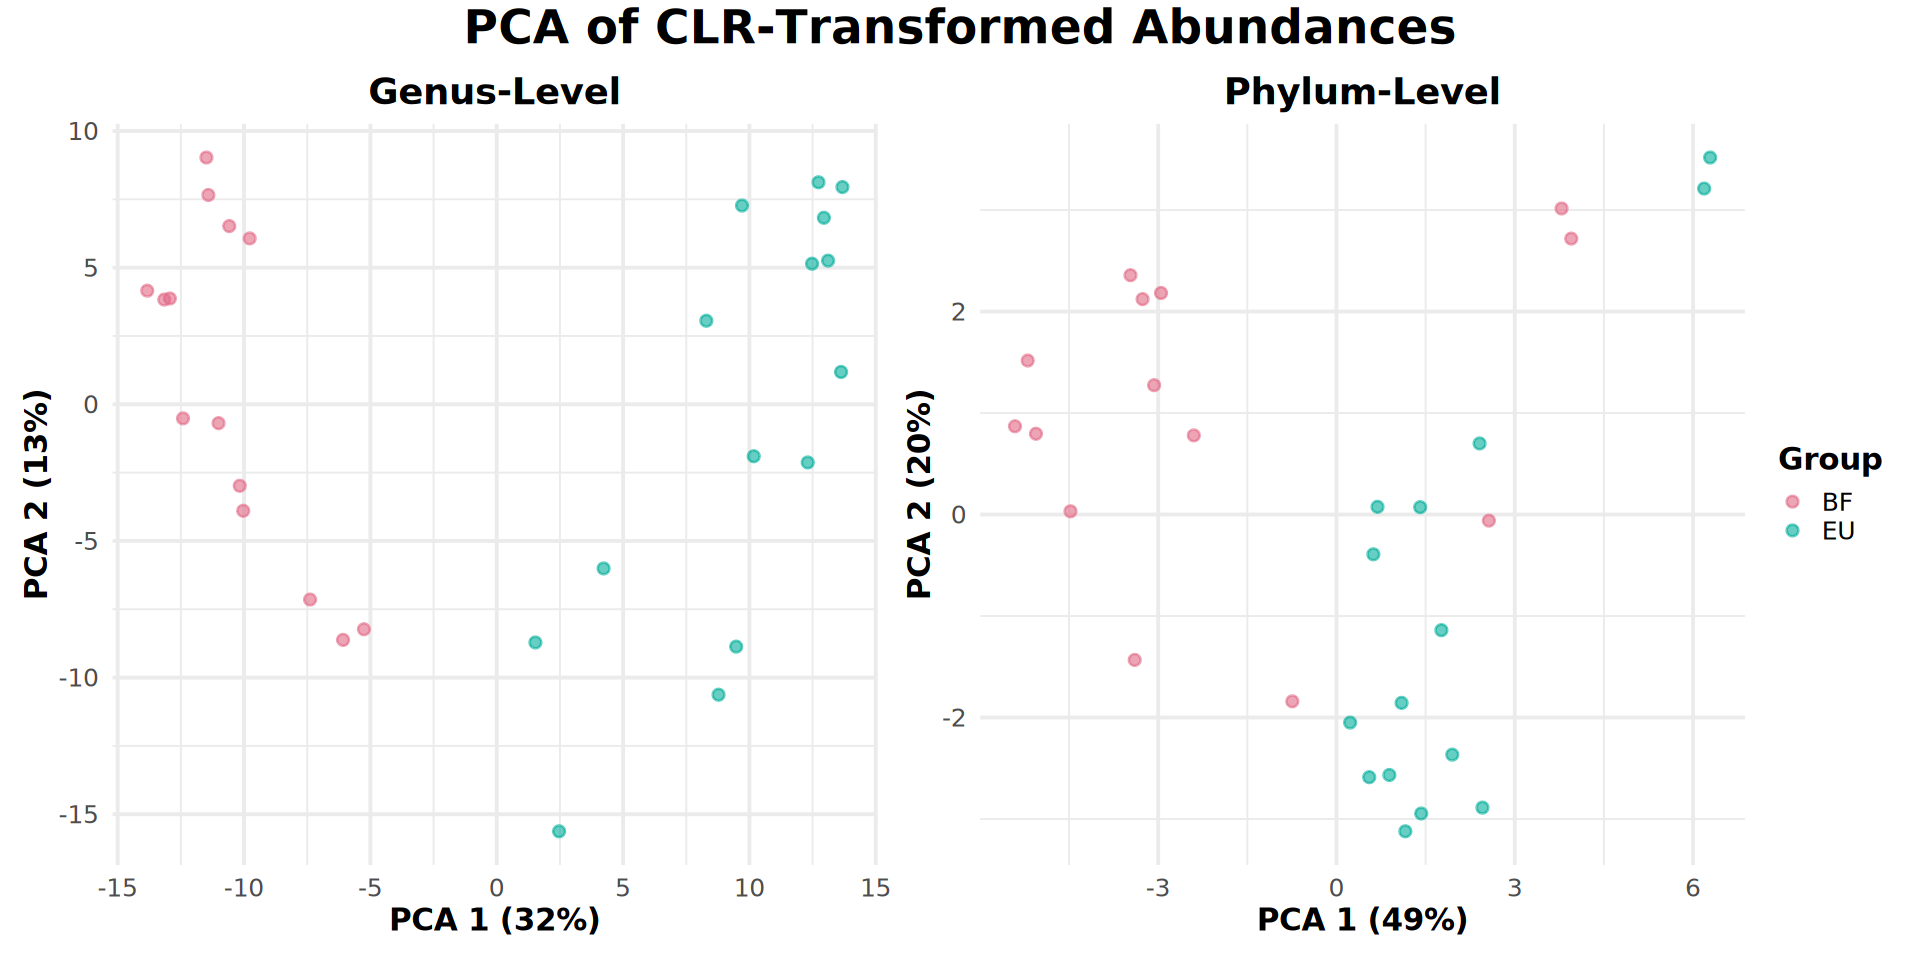

In [60]:
options(repr.plot.width = 16, repr.plot.height = 8)

p_pca_genus <- plotReducedDim(
    tse_clr_genus,
    dimred = "PCA",
    colour_by = "group"
) +
    labs(
        title = "Genus-Level",
        color = "Group"
    ) +
    theme_minimal(base_size = 18) +
    theme(
        plot.title = element_text(
            face = "bold",
            hjust = 0.5
        ),
        axis.title = element_text(face = "bold"),
        legend.title = element_text(face = "bold")
    ) + scale_color_manual(values = population_colors) 




p_pca_phylum <- plotReducedDim(
    tse_clr_phylum,
    dimred = "PCA",
    colour_by = "group"
) +
    labs(
        title = "Phylum-Level",
        color = "Group"
    ) +
    theme_minimal(base_size = 18) +
    theme(
        plot.title = element_text(
            face = "bold",
            hjust = 0.5
        ),
        axis.title = element_text(face = "bold"),
        legend.title = element_text(face = "bold")
    ) + scale_color_manual(values = population_colors) 







pca_plot <- (p_pca_genus + p_pca_phylum) +
    plot_layout(guides = "collect") +
    plot_annotation(
        title = "PCA of CLR-Transformed Abundances",
        theme = theme(
            plot.title = element_text(
                size = 28,
                face = "bold",
                hjust = 0.5
            )
        )
    ) +
    theme(
        legend.position = "right"
    ) 

pca_plot

In [61]:
# save figure 
ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.PCA.png'),
    plot = pca_plot,
    width = 16,
    height = 8,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.PCA.pdf'),
    plot = pca_plot,
    width = 16,
    height = 8,
    units = "in",
    bg = "white"
)


# save table for making figure in quarto report
saveRDS(tse_clr_genus, file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".tse_clr_genus.rds")))


# save table for making figure in quarto report
saveRDS(tse_clr_phylum, file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".tse_clr_phylum.rds")))


### Composition Heatmap

In [74]:
tse_clr_phylum

# A SingleCellExperiment-tibble abstraction: 29 × 32
# Features=10 | Cells=29 | Assays=counts, clr
   .cell Population run_id   population_group age_years sex   reported_ethnicity
   <chr> <chr>      <chr>    <chr>                <dbl> <chr> <chr>             
 1 12BF  BF         ERR0110… BF                       6 male  black african     
 2 17BF  BF         ERR0110… BF                       5 fema… black african     
 3 17EU  EU         ERR0110… EU                       5 male  caucasian         
 4 18EU  EU         ERR0110… EU                       3 fema… caucasian         
 5 19EU  EU         ERR0110… EU                       4 fema… caucasian         
 6 20EU  EU         ERR0110… EU                       5 fema… caucasian         
 7 21EU  EU         ERR0110… EU                       3 fema… caucasian         
 8 10EU  EU         ERR0110… EU                       5 male  caucasian         
 9 8EU   EU         ERR0110… EU                       5 male  caucasian         
10 5EU   E

In [130]:
make_neatMap_heatmap <- function(
    tse_clr1,
    popColumn1,
    popColumnRename,
    pop_colors1,
    titl1e,
    titleSize1, 
    axisSizeX, axisSizeY
) {

    # Sort by radial theta using the first two principal components
    sorted_order <- getNeatOrder(
        reducedDim(tse_clr1, "PCA")[, c(1, 2)],
        centering = "mean"
    )

    tse_clr1 <- tse_clr1[, sorted_order]

    # make dummy column so the pop column has the name I want
    colData(tse_clr1)[[popColumnRename]] <-
        colData(tse_clr1)[[popColumn1]]

    # dynamically construct annotation-color list
    anno_colors1 <- list(pop_colors1)
    names(anno_colors1) <- popColumnRename

    # plot NeatMap
    neatmap1 <- sechm(
        tse_clr1,
        assayName = "clr",
        features = rownames(tse_clr1),

        show_rownames = TRUE,
        show_colnames = TRUE,

        do.scale = FALSE,
        cluster_rows = FALSE,
        sortRowsOn = NULL,

        row_names_gp = gpar(fontsize = axisSizeX),
        column_names_gp = gpar(fontsize = axisSizeY),

        breaks = 1,
        hmcols = c("blue", "white", "red"),

        # annotation column
        top_annotation = popColumnRename,

        # annotation colors
        anno_colors = anno_colors1,

        column_title = titl1e,
        column_title_gp = gpar(
            fontsize = titleSize1,
            fontface = "bold"
        )
    )

    return(neatmap1)
}










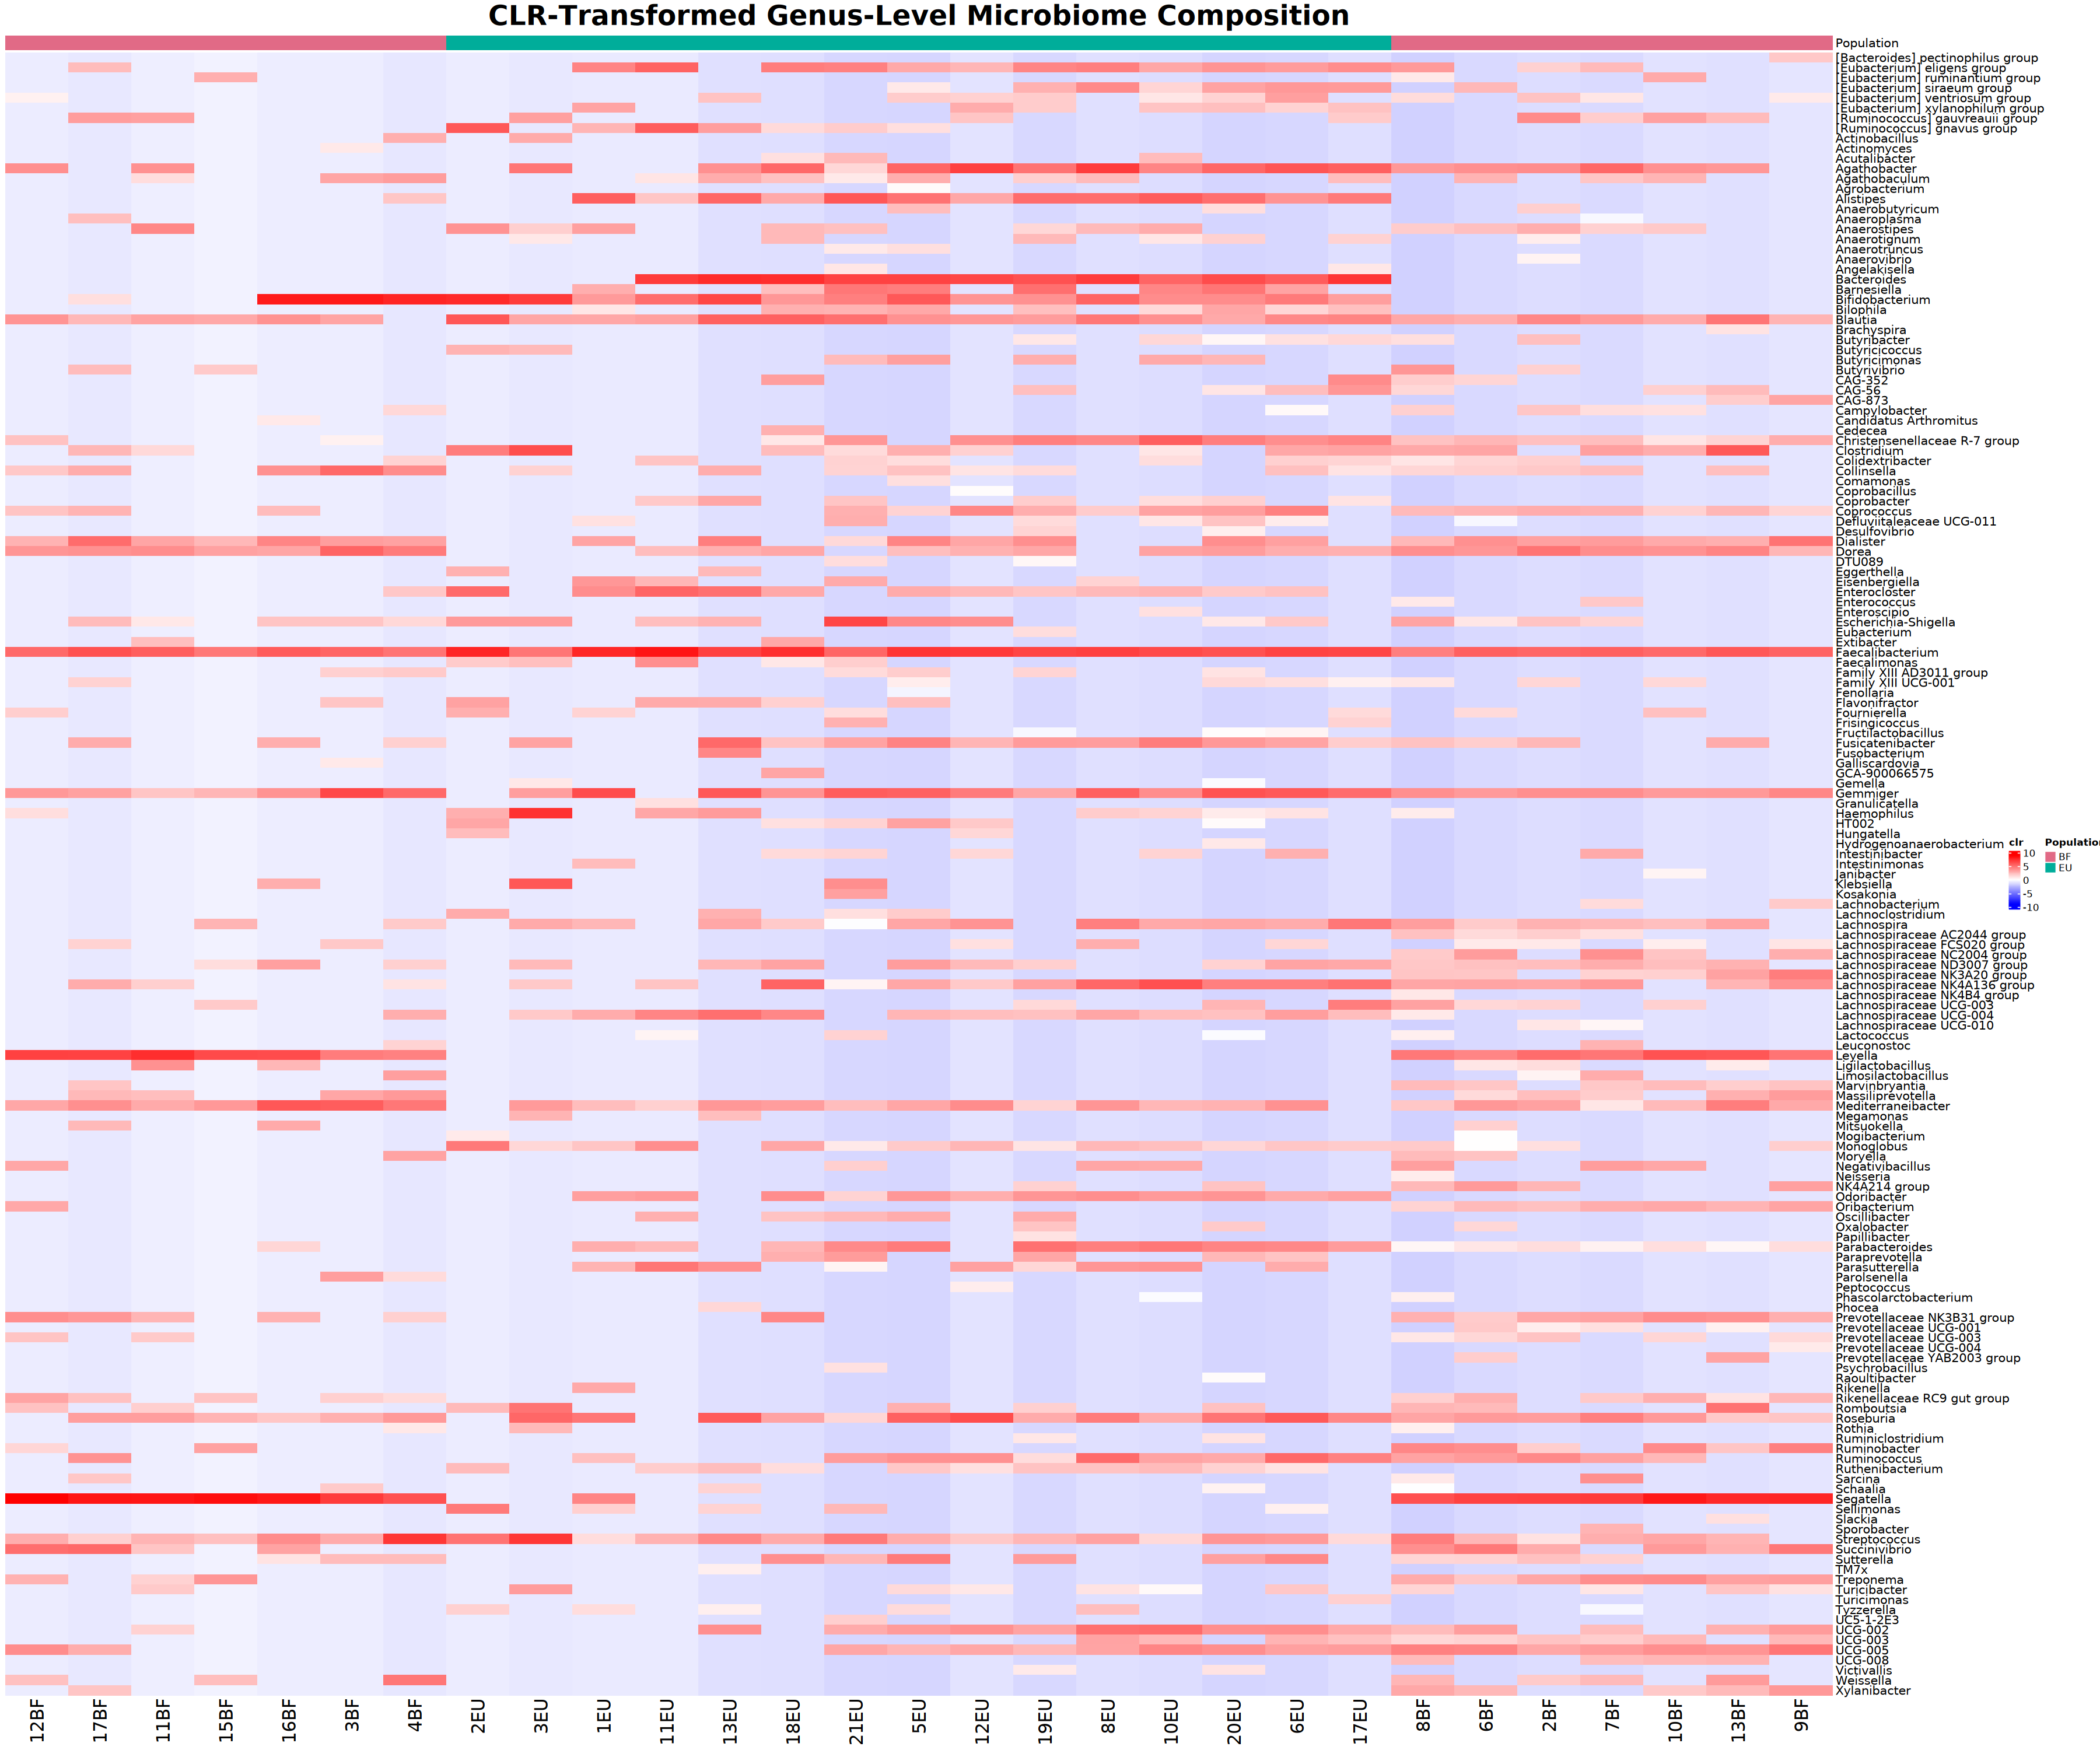

In [131]:
options(repr.plot.width = 30, repr.plot.height = 25)
ph_genus <- make_neatMap_heatmap( tse_clr1 = tse_clr_genus, popColumn1 = 'population_group', 
                     popColumnRename = 'Population', pop_colors1 = population_colors, 
                     titl1e = 'CLR-Transformed Genus-Level Microbiome Composition', 
                     titleSize1 = 28, axisSizeX = 12, axisSizeY = 18)
ph_genus

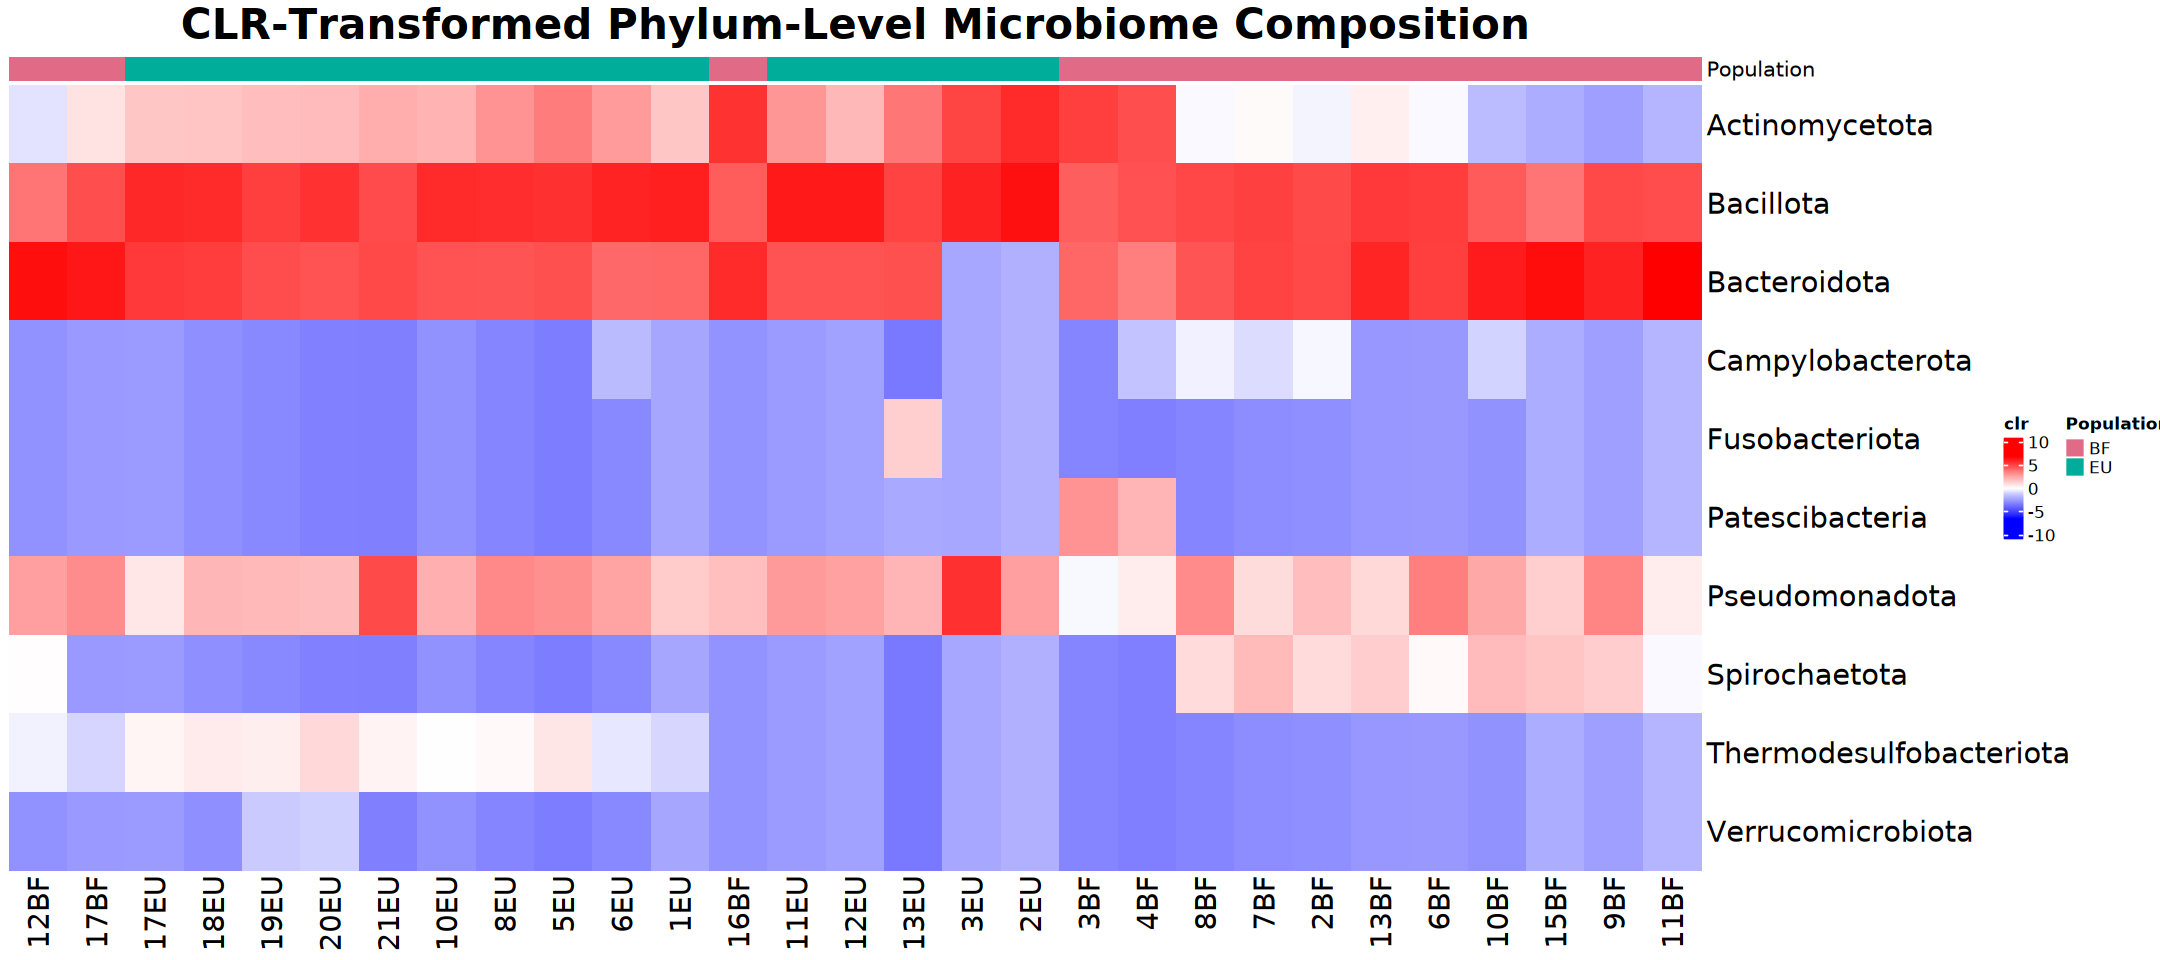

In [134]:
options(repr.plot.width = 18, repr.plot.height = 8)

ph_phylum <- make_neatMap_heatmap( tse_clr1 = tse_clr_phylum, popColumn1 = 'population_group', 
                     popColumnRename = 'Population', pop_colors1 = population_colors, 
                     titl1e = 'CLR-Transformed Phylum-Level Microbiome Composition', 
                     titleSize1 = 25, axisSizeX = 17, axisSizeY = 17)
ph_phylum

In [154]:
# save figure phylum
# ggsave(
#     filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.Phylum.Heatmap.png'),
#     plot = pca_plot,
#     width = 18,
#     height = 8,
#     units = "in",
#     dpi = 300,
#     bg = "white"
# )

# ggsave(
#     filename = paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.Phylum.Heatmap.pdf'),
#     plot = pca_plot,
#     width = 18,
#     height = 8,
#     units = "in",
#     bg = "white"
# )

png(
    paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.Phylum.Heatmap.png'),
    width = 18,
    height = 8,
    units = "in",
    res = 300
)

draw(ph_phylum)

dev.off()




pdf(
    paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.Phylum.Heatmap.png'),
    width = 18,
    height = 8
)

draw(ph_phylum)

dev.off()



outfile <- file.path(
    FIG_ABUND_DIV_DIR,
    paste0(PROJECT_NAME, ".taxaComposition.Phylum.Heatmap.pdf")
)


# graphics.off()
pdf(
    outfile,
    width = 18,
    height = 8
)

draw(ph_phylum)

dev.off()






# save figure genus

png(
    paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.Genus.Heatmap.png'),
    width = 15,
    height = 15,
    units = "in",
    res = 300
)

draw(ph_genus)

dev.off()



pdf(
    paste0(FIG_ABUND_DIV_DIR, '/', PROJECT_NAME, '.taxaComposition.Genus.Heatmap.pdf'),
    width = 15,
    height = 15
)

draw(ph_genus)

dev.off()




# Done above
# # save table for making figure in quarto report
# saveRDS(tse_clr_genus, file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".tse_clr_genus.rds")))


# # save table for making figure in quarto report
# saveRDS(tse_clr_phylum, file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".tse_clr_phylum.rds")))


agg_record_27fb53c9986a 
                      2

agg_record_27fb53c9986a 
                      2

agg_record_27fb53c9986a 
                      2

agg_record_27fb53c9986a 
                      2

agg_record_27fb53c9986a 
                      2

### Save objects for next notebook (even if object is redundant with the file saved for the report)

In [83]:
# save table for making figure in quarto report
saveRDS(tse, file = file.path(ABUND_DIV_DIR, paste0(PROJECT_NAME, ".tse.rds")))

# save table for making figure in quarto report
saveRDS(tse_genus, file = file.path(ABUND_DIV_DIR, paste0(PROJECT_NAME, ".tse_genus.rds")))


# save table for making figure in quarto report
saveRDS(tse_phylum, file = file.path(ABUND_DIV_DIR, paste0(PROJECT_NAME, ".tse_phylum.rds")))

